# we will test the CAGE and RNA and TSS based models

For CAGE it is easiest

For RNA probalby use seq mask

For TSS, make sure we don't softplus a second time

In [1]:
#we need to load the model and load the gold standard df and also the tss information dicts

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t", header=None)

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")
gs_df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,"Gasperini et al., 2019",False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,Ulirsch2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,"Gasperini et al., 2019",False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10407,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,"Gasperini et al., 2019",False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408
10408,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569
10409,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,"Gasperini et al., 2019",False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408
10410,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,"Gasperini et al., 2019",False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408


In [2]:
k562_file = '/data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/K562_DNase.npz'
with np.load(k562_file) as k562_file:
    k562 = {key: np.array(k562_file[key]) for key in k562_file}


In [3]:
gs_df.columns

Index(['dataset', 'chrom', 'chromStart', 'chromEnd', 'name', 'EffectSize',
       'chrTSS', 'startTSS', 'endTSS', 'measuredGeneSymbol', 'Significant',
       'pValueAdjusted', 'PowerAtEffectSize25', 'ValidConnection', 'CellType',
       'Reference', 'Regulated', 'PowerAtEffectSize10', 'PowerAtEffectSize15',
       'PowerAtEffectSize20', 'PowerAtEffectSize50', 'pair_uid', 'merged_uid',
       'merged_start', 'merged_end'],
      dtype='object')

In [4]:
#now filter to the largest ones
gs_df_regulated = gs_df[gs_df["Regulated"] == True] #487
#now sort it by absolute value of EffectSize column
gs_df_regulated = gs_df_regulated.reindex(gs_df_regulated["EffectSize"].abs().sort_values(ascending=False).index)
gs_df_regulated

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Reference,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end
3387,FlowFISH_K562,chr17,32909510,32913691,TMEM98|chr17:31236528-31240709:*,-0.932000,chr17,32927910.0,32927911.0,TMEM98,...,Huang2018,True,NaN,NaN,NaN,NaN,FlowFISH_K562|TMEM98|chr17:31236528-31240709:*,3388,32909510,32913691
10345,FlowFISH_K562,chrX,55028229,55028268,ALAS2|chrX:55054662-55054701:*,-0.930000,chrX,55031063.0,55031064.0,ALAS2,...,Wakabayashi2016,True,NaN,NaN,NaN,NaN,FlowFISH_K562|ALAS2|chrX:55054662-55054701:*,10346,55028229,55028268
5267,FlowFISH_K562,chr19,48963708,48964208,FTL|chr19:49466965-49467465:*,-0.900693,chr19,48965301.0,48965302.0,FTL,...,Fulco2019,True,NaN,NaN,NaN,NaN,FlowFISH_K562|FTL|chr19:49466965-49467465:*,5268,48963708,48964208
2668,FlowFISH_K562,chr12,54304241,54304761,NFE2|chr12:54698025-54698545:*,-0.892641,chr12,54301120.0,54301121.0,NFE2,...,Fulco2019,True,NaN,NaN,NaN,NaN,FlowFISH_K562|NFE2|chr12:54698025-54698545:*,2669,54304241,54304761
8068,FlowFISH_K562,chr6,37183271,37183514,PIM1|chr6:37151047-37151290:*,-0.888781,chr6,37170203.0,37170204.0,PIM1,...,Xie2017,True,NaN,NaN,NaN,NaN,FlowFISH_K562|PIM1|chr6:37151047-37151290:*,8069,37183271,37183514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9340,Gasperini2019,chr8,141021719,141022914,RP11-809O17.1|chr8:142031818-142033013:.,-0.004163,chr8,141129960.0,141129961.0,RP11-809O17.1,...,"Gasperini et al., 2019",True,0.00,0.0,0.00,0.00,Gasperini2019|RP11-809O17.1|chr8:142031818-142...,9341,141021719,141022914
2162,Gasperini2019,chr11,65362343,65362917,FIBP|chr11:65129814-65130388:.,-0.003123,chr11,65888538.0,65888539.0,FIBP,...,"Gasperini et al., 2019",True,0.45,0.6,0.80,1.00,Gasperini2019|FIBP|chr11:65129814-65130388:.,2163,65362343,65362917
851,Gasperini2019,chr10,12265775,12266275,SEC61A2|chr10:12307774-12308274:.,-0.001270,chr10,12129637.0,12129638.0,SEC61A2,...,"Gasperini et al., 2019",True,0.00,0.0,0.00,0.10,Gasperini2019|SEC61A2|chr10:12307774-12308274:.,852,12265775,12266275
8219,Gasperini2019,chr6,144215306,144215806,PLAGL1|chr6:144536443-144536943:.,-0.000975,chr6,144064598.0,144064599.0,PLAGL1,...,"Gasperini et al., 2019",True,0.00,0.1,0.25,0.75,Gasperini2019|PLAGL1|chr6:144536443-144536943:.,8220,144215306,144215806


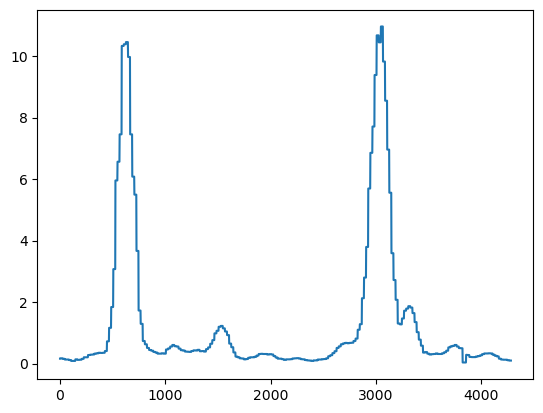

In [5]:
#let's plot the 
import matplotlib.pyplot as plt
temp = gs_df_regulated.iloc[0]
chrom = temp['chrom']
start = temp['chromStart']
end = temp['chromEnd']
track = k562[chrom][0,start-50:end+50]

plt.plot(track) #isthese 2 big peaks

In [6]:
import torch
a = torch.tensor([1, 2, 3])
a.cuda()

tensor([1, 2, 3], device='cuda:0')

In [7]:
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
import torch
from tqdm import tqdm
from src.dataloaders.datasets.general_dataset import GeneralDataset
from src.models.sequence.dna_embedding import DNAEmbeddingModelCaduceus
from src.tasks.decoders import EnformerDecoder
from src.tasks.encoders import JointCNN
from caduceus.configuration_caduceus import CaduceusConfig
import yaml
from omegaconf import OmegaConf
import os
import itertools
import inspect
try:
    OmegaConf.register_new_resolver('eval', eval)
    OmegaConf.register_new_resolver('div_up', lambda x, y: (x + y - 1) // y)
except ValueError as e:
    if "Resolver already registered" in str(e):
            print("Resolver already exists, skipping registration.")

In [22]:

# from evals_utils_joint import Evals
class Evals():
    def __init__(self,
                 ckpt_path,
                 dataset=None,
                 split = 'test',
                 device = None,
                 load_data=False,
                 **dataset_overrides #Don't pass None into overrides unless you intentionally want it to be None! Pass in items only that you need
                 ) -> None:
        
        #now load the cfg from the checkpoint path
        model_cfg_path = os.path.join(os.path.dirname(os.path.dirname(ckpt_path)), '.hydra', 'config.yaml')
        cfg = yaml.load(open(model_cfg_path, 'r'), Loader=yaml.FullLoader)
        cfg = OmegaConf.create(cfg)
        self.cfg = OmegaConf.to_container(cfg, resolve=True)
        
        state_dict = torch.load(ckpt_path, map_location='cpu')
        if device is not None:
            #if we are given a device, we will use that device
            self.device = torch.device(device)
        else:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.split = split

        #now set up dataset
        if dataset is None:
            dataset_args = self.cfg['dataset']
            assert dataset_args['mlm'] == 0 and dataset_args['acc_mlm'] == 0, "MLM and acc_mlm should be 0 for the training"
            sig = inspect.signature(GeneralDataset.__init__)
            sig = {k: v for k, v in sig.parameters.items() if k != 'self'}
            to_remove = []
            for k, v in dataset_args.items():
                if k not in sig:
                    # del dataset_args[k]
                    to_remove.append(k)
            for k in to_remove:
                del dataset_args[k]
            dataset_args['split'] = split
            dataset_args['evaluating'] = True #this tells it to not do things like random shifting and rc aug, still does random masking tho, can get og sequence easily
            dataset_args['load_in'] = load_data
            
            for k, v in dataset_overrides.items():
                if k in sig:
                    dataset_args[k] = v
                    print(f"Overriding {k} with {v}")
                else:
                    print(f"Warning: {k} not in dataset args, skipping")
            
            # dataset_args['rc_aug'] = False #we don't want to do rc aug in our evaluation class!!!
            self.dataset_args = dataset_args
            # self.dataset_args['rc_aug'] = False #we don't want to do rc aug in our evaluation class!!!
            self.dataset = GeneralDataset(**dataset_args)
            
            # self.kmer_len = dataset_args['kmer_len']
            # self.dataset = enformer_dataset.EnformerDataset(split, dataset_args['max_length'], rc_aug = dataset_args['rc_aug'],
            #                                                 return_CAGE=dataset_args['return_CAGE'], cell_type=dataset_args.get('cell_type', None),
            #                                                 kmer_len=dataset_args['kmer_len']) #could use dataloader instead, but again kinda complex
        else:
            self.dataset = dataset
         
        torch.nn.modules.utils.consume_prefix_in_state_dict_if_present(
            state_dict["state_dict"], "model."
        )
        model_state_dict = state_dict["state_dict"]
        # need to remove torchmetrics. to remove keys, need to convert to list first
        for key in list(model_state_dict.keys()):
            if "torchmetrics" in key:
                model_state_dict.pop(key)
        # the state_dict keys slightly mismatch from Lightning..., so we fix it here
        decoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "decoder" in key:
                decoder_state_dict[key[10:]] = model_state_dict.pop(key)
        encoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "encoder" in key:
                encoder_state_dict[key[10:]] = model_state_dict.pop(key)
        
        cfg['model']['config'].pop('_target_')
        # cfg['model']['config']['complement_map'] = self.dataset.tokenizer.complement_map
        caduceus_cfg = CaduceusConfig(**cfg['model']['config'])
        
        self.backbone = DNAEmbeddingModelCaduceus(config=caduceus_cfg)
        self.backbone.load_state_dict(model_state_dict, strict=True)
        
        #remove self.cfg['decoder']['_name_']
        del self.cfg['decoder']['_name_']
        self.cfg['decoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.decoder = EnformerDecoder(**self.cfg['decoder']) #could do with instantiating, but that is rather complex
        self.decoder.load_state_dict(decoder_state_dict, strict=True)
        
        del self.cfg['encoder']['_name_']
        self.cfg['encoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.encoder = JointCNN(**self.cfg['encoder'])
        self.encoder.load_state_dict(encoder_state_dict, strict=True)
        
        self.encoder.to(self.device).eval()
        self.backbone.to(self.device).eval()
        self.decoder.to(self.device).eval()
        
    def __call__(self, idx=None, data=None):
        #now evaluate the model on one example
        if data is None:
            (seq,acc),_ = self.dataset[idx]
            
            x = seq.unsqueeze(0)
            y = acc.unsqueeze(0)
        else:
            (x,y),_ = data

            if x.dim() == 2:
                x = x.unsqueeze(0) #add batch dim
                y = y.unsqueeze(0) #add batch dim
        
        x,y = x.to(self.device), y.to(self.device)
        
        with torch.no_grad():
            x1,_ = self.encoder(x,y)
            x1,_ = self.backbone(x1)
            x1 = self.decoder(x1)
        
        return x1

#this is the model that was trained on unstranded cage at 128 bp resolution. Let's see if it even predicts these values!
ckpt_path = '/data1/lesliec/sarthak/caduceus/outputs/2025-08-15/12-23-01-318424/checkpoints/last.ckpt'
evals = Evals(ckpt_path,load_data=False, device=0)

#first we have to see the prediction of this region, then extend the dataset

JointMaskingEncoder: d_model=256, celltypes=None, d_input1=6, d_input2=None, joint=False, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>


In [9]:
a = evals.dataset[0]
len(a)

2

In [10]:
idx = 0
(seq,acc),(seq_unmask,acc_unmask,additional) = evals.dataset[idx]
print(seq.shape, acc.shape, seq_unmask.shape, acc_unmask.shape, additional.shape)

torch.Size([6, 524288]) torch.Size([2, 524288]) torch.Size([524288, 6]) torch.Size([524288, 2]) (896, 1)


In [11]:
#and go through the call funciton
x = seq.unsqueeze(0).to(evals.device)
y = acc.unsqueeze(0).to(evals.device)
with torch.no_grad():
    x1,_ = evals.encoder(x,y)
    x1,_ = evals.backbone(x1)
    x1 = evals.decoder(x1)

In [12]:
#test the model outputs first for a random example
idx = 0
pred = evals(idx)
pred = pred.cpu().numpy().squeeze()
pred.shape

(896,)

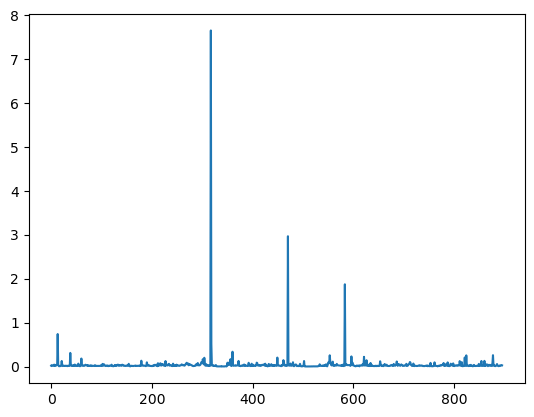

In [13]:
#now plot it
plt.plot(pred) #should see some peak! Let's see where the peak we're looking for even is

In [14]:
gs_df_regulated.iloc[0]

dataset                                                 FlowFISH_K562
chrom                                                           chr17
chromStart                                                   32909510
chromEnd                                                     32913691
name                                 TMEM98|chr17:31236528-31240709:*
EffectSize                                                     -0.932
chrTSS                                                          chr17
startTSS                                                   32927910.0
endTSS                                                     32927911.0
measuredGeneSymbol                                             TMEM98
Significant                                                      True
pValueAdjusted                                                    NaN
PowerAtEffectSize25                                               1.0
ValidConnection                                                  True
CellType            

In [15]:
#find TSS from the tss dict
tss_dict_file = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
import json
with open(tss_dict_file, 'r') as f:
    tss_dict = json.load(f)
    
tss_dict


{'ENSG00000186092': {'chrom': 'chr1',
  'counts': 0.0,
  'tss': 69090,
  'alt_tss': [65419],
  'strand': '+',
  'split': 'train'},
 'ENSG00000187634': {'chrom': 'chr1',
  'counts': 1.1043366598147355,
  'tss': 925740,
  'alt_tss': [925731, 930312, 939275, 923923, 923924, 925942, 925150],
  'strand': '+',
  'split': 'train'},
 'ENSG00000188976': {'chrom': 'chr1',
  'counts': 6.783325684813521,
  'tss': 959299,
  'alt_tss': [959244,
   959250,
   959251,
   959256,
   959260,
   959262,
   959263,
   959265,
   959266,
   959267,
   959270,
   959271,
   959276,
   959277,
   959278,
   959283,
   959284,
   959285,
   959286,
   959293,
   959300,
   960714],
  'strand': '-',
  'split': 'train'},
 'ENSG00000187961': {'chrom': 'chr1',
  'counts': 9.189972773359631,
  'tss': 960586,
  'alt_tss': [960576, 960581, 960584, 960585, 960586, 960595, 960599],
  'strand': '+',
  'split': 'train'},
 'ENSG00000187583': {'chrom': 'chr1',
  'counts': 1.5210507369009632,
  'tss': 966496,
  'alt_tss': 

In [16]:
# tss_dict['TMEM98'] #oh shit have to convert to ENSG ID
#manually it is 
tss_dict['ENSG00000006042'] #clearly highly expressed

{'chrom': 'chr17',
 'counts': 5.98436149044871,
 'tss': 32927909,
 'alt_tss': [32928014,
  32928153,
  32928160,
  32928035,
  32928165,
  32927910,
  32928045,
  32928173,
  32928174,
  32928183,
  32928184,
  32928190,
  32928191,
  32928071,
  32928200,
  32928204,
  32928210,
  32931034,
  32928103,
  32928124],
 'strand': '+',
 'split': 'train'}

In [18]:
#so let's find distance between element and TSS
element = gs_df_regulated.iloc[0]
mid = (element['chromEnd']+element['chromStart'])//2
temp_tss = tss_dict['ENSG00000006042']['tss']
mid,temp_tss, mid-temp_tss #so it is 16000 to the left of the tss on the plus strand, makes sense lol

(32911600, 32927909, -16309)

In [19]:
#now let's plot this sequence
evals.dataset.length #this lets us give our start and end directly from the thing and it will expand it

524288

In [23]:
#let's plot based on the start and stop area by extending dataset
evals.dataset.expand_seqs('chr17',element['chromStart'], element['chromEnd'])

1937

In [24]:
#now let's get this data
#have to set additional data to None because we don't have tracks we're loading but rather set sequences
evals.dataset.additional_data

<Group file:///data1/lesliec/sarthak/data/enformer/data/labels.zarr>

In [32]:
evals.dataset.additional_data = None
evals.dataset.additional_data_path = None

In [33]:
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[1937]
print(seq.shape, acc.shape, seq_unmask.shape, acc_unmask.shape)

torch.Size([6, 524288]) torch.Size([2, 524288]) torch.Size([524288, 6]) torch.Size([524288, 2])


In [34]:
#let's now predict an output
out = evals(1937)
print(out.shape)

torch.Size([1, 896, 1])


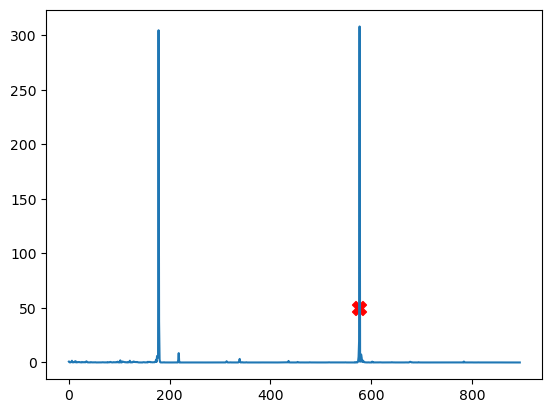

In [42]:
#let's plot it
plt.plot(out.cpu().numpy().squeeze())
#and also plot the difference between the midpoint and the start area
#so we draw a vertical line at midpoint + 16309//128
# plt.axvline(x=896//2 + 16309//128, color='r', linestyle='--')
#perfectly sits on a cage peak! Let's make it not a vertical line but a horizontal marker above the peak
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)

In [43]:
#now let's rerun the output after setting peak to 0
acc.shape

torch.Size([2, 524288])

In [44]:
acc.sum(1)

tensor([64477.2344,     0.0000])

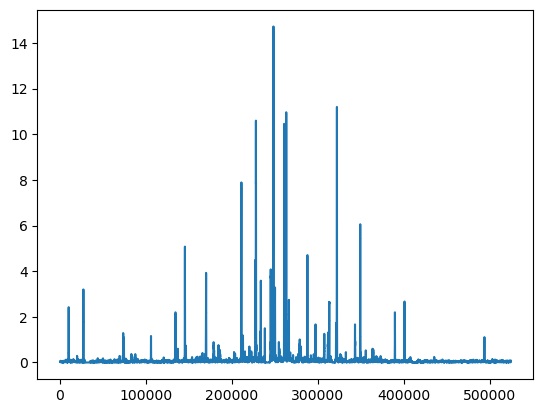

In [59]:
plt.plot(acc[0].cpu().numpy()) #can see the middle 5000 is now 0

In [ ]:
element['chromEnd']-element['chromStart'] #set middle 5000 lower

4181

In [60]:
mid_acc = acc.shape[1]//2
acc[0,mid_acc-2500:mid_acc+2500] = 0

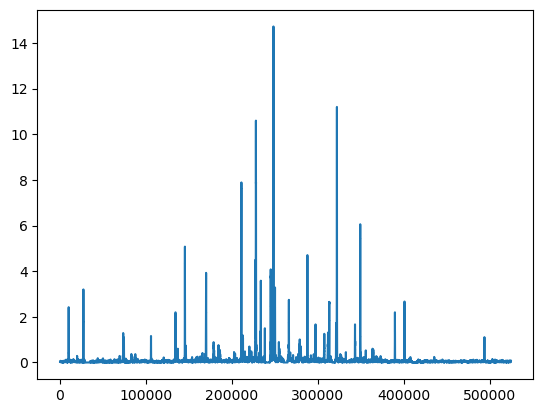

In [ ]:
plt.plot(acc[0]) #2 of the peaks are gone!!

In [62]:
acc.sum(1)

tensor([58774.0391,     0.0000])

In [63]:
#now rerun it
out = evals(data=((seq,acc), (seq_unmask, acc_unmask)))

In [49]:
out.shape

torch.Size([1, 896, 1])

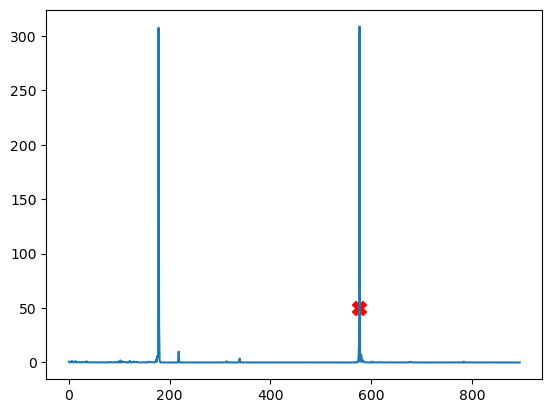

In [65]:
#plot it
plt.plot(out.cpu().numpy().squeeze())
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)

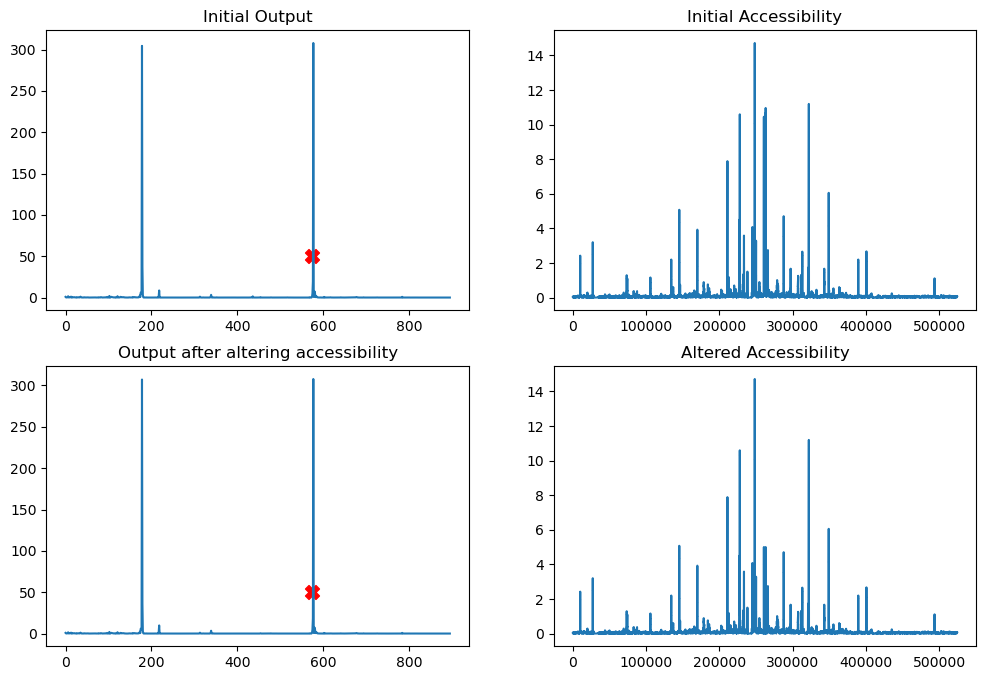

In [67]:
#maybe setting acc to 0 doens't work well, let's reduce the accessibility by about half then?
#make this whole thing more systematic

idx_gs = 0
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
temp_tss = tss_dict['ENSG00000006042']['tss'] #this part of converting to ENSG needs to be done!

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1.cpu().numpy().squeeze())
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
acc[0,mid_acc-2500:mid_acc+2500] = acc[0,mid_acc-2500:mid_acc+2500]//2 #reduce by half
out2 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))

plt.plot(out2.cpu().numpy().squeeze())
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc[0].cpu().numpy())

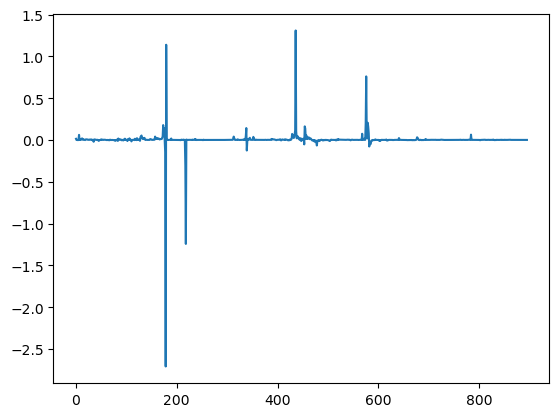

In [ ]:
plt.plot((out1-out2).cpu().numpy().squeeze())
#differences are not really visible..

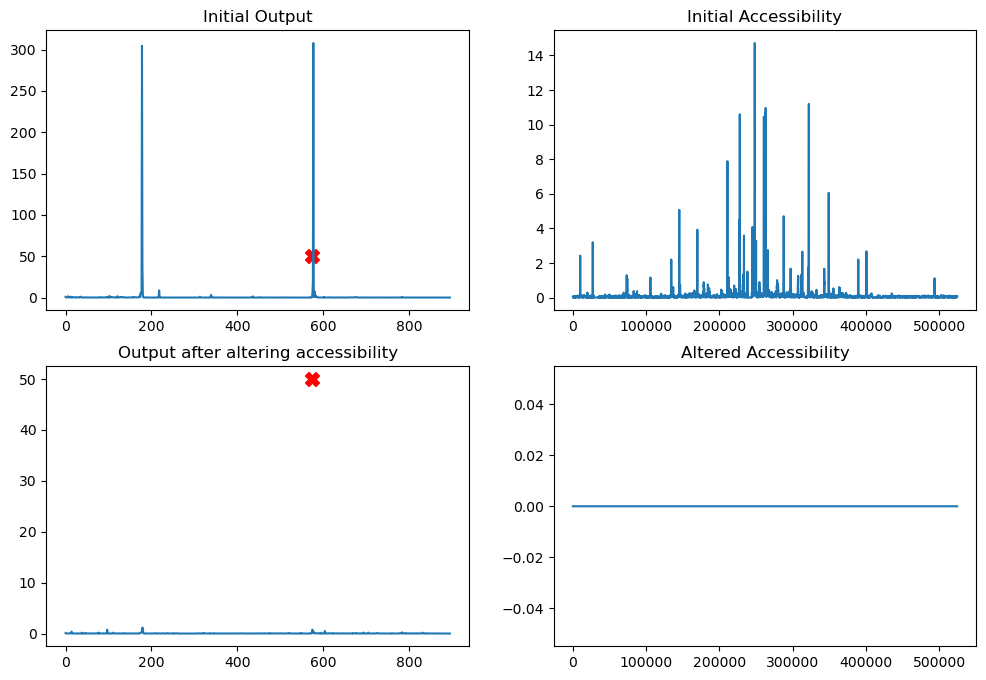

In [ ]:
#let's do something more drstic

idx_gs = 0
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
temp_tss = tss_dict['ENSG00000006042']['tss'] #this part of converting to ENSG needs to be done!

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1.cpu().numpy().squeeze())
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
# acc[0,mid_acc-2500:mid_acc+2500] = acc[0,mid_acc-2500:mid_acc+2500]//2 #reduce by half
acc[0]=0
out2 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))

plt.plot(out2.cpu().numpy().squeeze())
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc[0].cpu().numpy())
#clealry uses the information!! This is really good to see

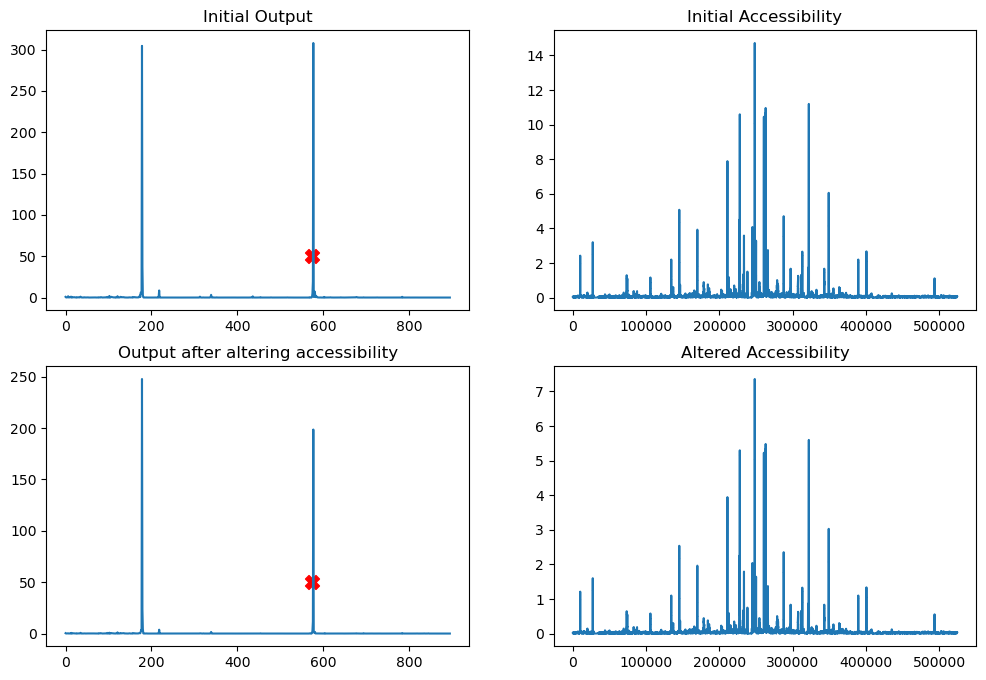

In [ ]:
#let's try reducing without setting it to 0
idx_gs = 0
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
temp_tss = tss_dict['ENSG00000006042']['tss'] #this part of converting to ENSG needs to be done!

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1.cpu().numpy().squeeze())
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
# acc[0,mid_acc-5000:mid_acc+5000] = acc[0,mid_acc-5000:mid_acc+5000]//100 #reduce by half
acc[0]=acc[0]/2
out2 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))

plt.plot(out2.cpu().numpy().squeeze())
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc[0].cpu().numpy())
#clealry uses the information!! This is really good to see

# redo but make it smarter

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t", header=None)

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

gs_df_regulated = gs_df[gs_df["Regulated"] == True] #487
#now sort it by absolute value of EffectSize column
gs_df_regulated = gs_df_regulated.reindex(gs_df_regulated["EffectSize"].abs().sort_values(ascending=False).index)

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)

In [5]:
#and the evals dataset
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
import torch
from tqdm import tqdm
from src.dataloaders.datasets.general_dataset import GeneralDataset
from src.models.sequence.dna_embedding import DNAEmbeddingModelCaduceus
from src.tasks.decoders import EnformerDecoder
from src.tasks.encoders import JointCNN
from caduceus.configuration_caduceus import CaduceusConfig
import yaml
from omegaconf import OmegaConf
import os
import itertools
import inspect
try:
    OmegaConf.register_new_resolver('eval', eval)
    OmegaConf.register_new_resolver('div_up', lambda x, y: (x + y - 1) // y)
except ValueError as e:
    if "Resolver already registered" in str(e):
            print("Resolver already exists, skipping registration.")

# from evals_utils_joint import Evals
class Evals():
    def __init__(self,
                 ckpt_path,
                 dataset=None,
                 split = 'test',
                 device = None,
                 load_data=False,
                 **dataset_overrides #Don't pass None into overrides unless you intentionally want it to be None! Pass in items only that you need
                 ) -> None:
        
        #now load the cfg from the checkpoint path
        model_cfg_path = os.path.join(os.path.dirname(os.path.dirname(ckpt_path)), '.hydra', 'config.yaml')
        cfg = yaml.load(open(model_cfg_path, 'r'), Loader=yaml.FullLoader)
        cfg = OmegaConf.create(cfg)
        self.cfg = OmegaConf.to_container(cfg, resolve=True)
        
        state_dict = torch.load(ckpt_path, map_location='cpu')
        if device is not None:
            #if we are given a device, we will use that device
            self.device = torch.device(device)
        else:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.split = split

        #now set up dataset
        if dataset is None:
            dataset_args = self.cfg['dataset']
            assert dataset_args['mlm'] == 0 and dataset_args['acc_mlm'] == 0, "MLM and acc_mlm should be 0 for the training"
            sig = inspect.signature(GeneralDataset.__init__)
            sig = {k: v for k, v in sig.parameters.items() if k != 'self'}
            to_remove = []
            for k, v in dataset_args.items():
                if k not in sig:
                    # del dataset_args[k]
                    to_remove.append(k)
            for k in to_remove:
                del dataset_args[k]
            dataset_args['split'] = split
            dataset_args['evaluating'] = True #this tells it to not do things like random shifting and rc aug, still does random masking tho, can get og sequence easily
            dataset_args['load_in'] = load_data
            
            for k, v in dataset_overrides.items():
                if k in sig:
                    dataset_args[k] = v
                    print(f"Overriding {k} with {v}")
                else:
                    print(f"Warning: {k} not in dataset args, skipping")
            
            # dataset_args['rc_aug'] = False #we don't want to do rc aug in our evaluation class!!!
            self.dataset_args = dataset_args
            # self.dataset_args['rc_aug'] = False #we don't want to do rc aug in our evaluation class!!!
            self.dataset = GeneralDataset(**dataset_args)
            
            # self.kmer_len = dataset_args['kmer_len']
            # self.dataset = enformer_dataset.EnformerDataset(split, dataset_args['max_length'], rc_aug = dataset_args['rc_aug'],
            #                                                 return_CAGE=dataset_args['return_CAGE'], cell_type=dataset_args.get('cell_type', None),
            #                                                 kmer_len=dataset_args['kmer_len']) #could use dataloader instead, but again kinda complex
        else:
            self.dataset = dataset
         
        torch.nn.modules.utils.consume_prefix_in_state_dict_if_present(
            state_dict["state_dict"], "model."
        )
        model_state_dict = state_dict["state_dict"]
        # need to remove torchmetrics. to remove keys, need to convert to list first
        for key in list(model_state_dict.keys()):
            if "torchmetrics" in key:
                model_state_dict.pop(key)
        # the state_dict keys slightly mismatch from Lightning..., so we fix it here
        decoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "decoder" in key:
                decoder_state_dict[key[10:]] = model_state_dict.pop(key)
        encoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "encoder" in key:
                encoder_state_dict[key[10:]] = model_state_dict.pop(key)
        
        cfg['model']['config'].pop('_target_')
        # cfg['model']['config']['complement_map'] = self.dataset.tokenizer.complement_map
        caduceus_cfg = CaduceusConfig(**cfg['model']['config'])
        
        self.backbone = DNAEmbeddingModelCaduceus(config=caduceus_cfg)
        self.backbone.load_state_dict(model_state_dict, strict=True)
        
        #remove self.cfg['decoder']['_name_']
        del self.cfg['decoder']['_name_']
        self.cfg['decoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.decoder = EnformerDecoder(**self.cfg['decoder']) #could do with instantiating, but that is rather complex
        self.decoder.load_state_dict(decoder_state_dict, strict=True)
        
        del self.cfg['encoder']['_name_']
        self.cfg['encoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.encoder = JointCNN(**self.cfg['encoder'])
        self.encoder.load_state_dict(encoder_state_dict, strict=True)
        
        self.encoder.to(self.device).eval()
        self.backbone.to(self.device).eval()
        self.decoder.to(self.device).eval()
        
    def __call__(self, idx=None, data=None):
        #now evaluate the model on one example
        if data is None:
            (seq,acc),_ = self.dataset[idx]
            
            x = seq.unsqueeze(0)
            y = acc.unsqueeze(0)
        else:
            (x,y),_ = data

            if x.dim() == 2:
                x = x.unsqueeze(0) #add batch dim
                y = y.unsqueeze(0) #add batch dim
        
        x,y = x.to(self.device), y.to(self.device)
        
        with torch.no_grad():
            x1,_ = self.encoder(x,y)
            x1,_ = self.backbone(x1)
            x1 = self.decoder(x1)
        
        return x1

#this is the model that was trained on unstranded cage at 128 bp resolution. Let's see if it even predicts these values!
ckpt_path = '/data1/lesliec/sarthak/caduceus/outputs/2025-08-15/12-23-01-318424/checkpoints/last.ckpt'
evals = Evals(ckpt_path,load_data=False, device=0)

#first we have to see the prediction of this region, then extend the dataset

JointMaskingEncoder: d_model=256, celltypes=None, d_input1=6, d_input2=None, joint=False, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>


In [6]:
evals.dataset.additional_data = None
evals.dataset.additional_data_path = None

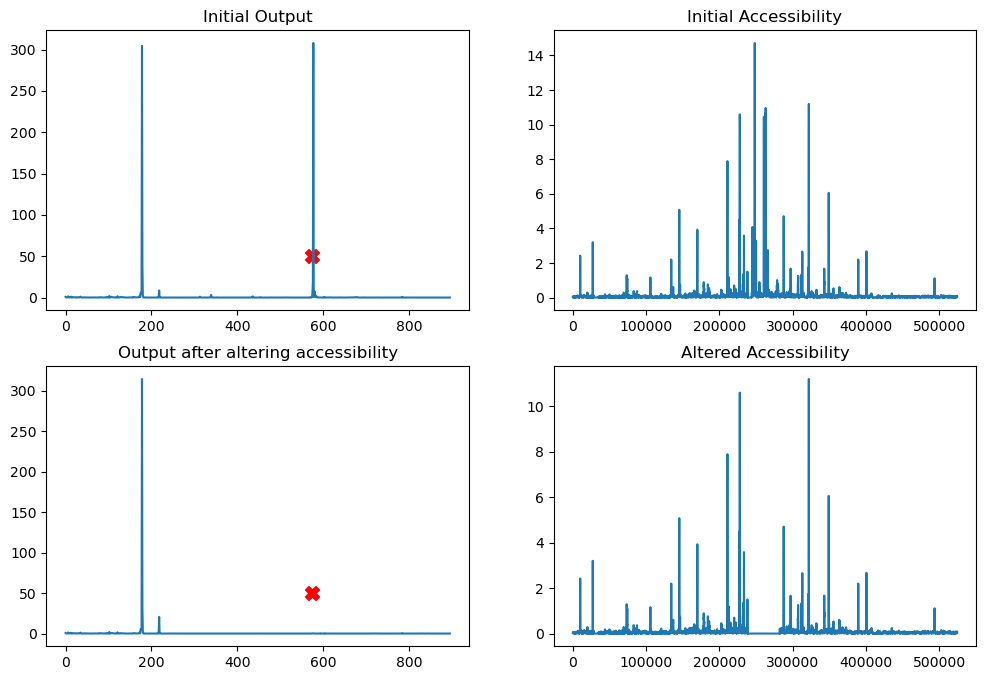

In [10]:
#clearly is using the accessibility info somehow?? so maybe need to expand the regions it is masking

idx_gs = 0
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
temp_tss = tss_dict['ENSG00000006042']['tss'] #this part of converting to ENSG needs to be done!

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1.cpu().numpy().squeeze())
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = 20000
acc[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))

plt.plot(out2.cpu().numpy().squeeze())
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc[0].cpu().numpy())
#clealry uses the information!! This is really good to see

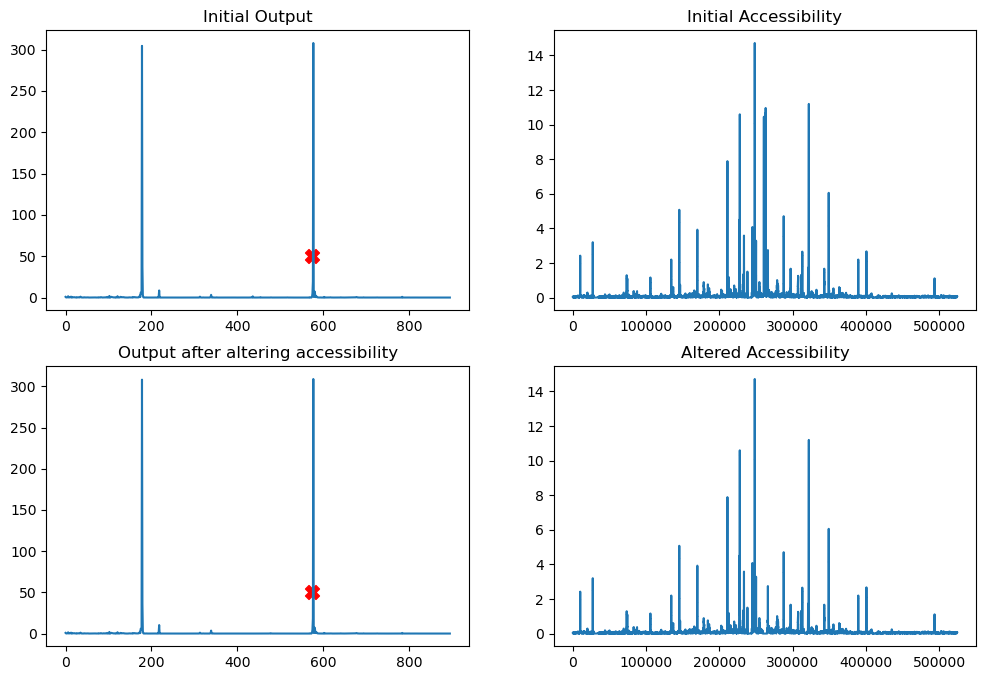

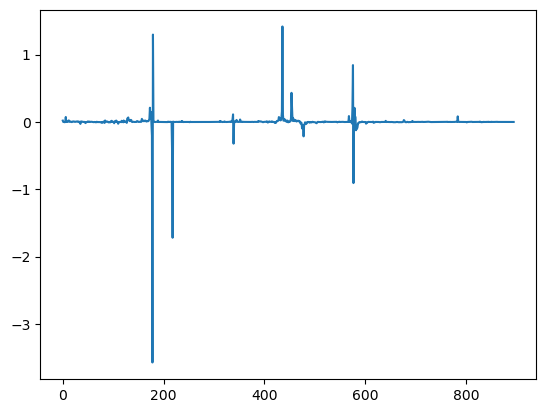

In [12]:
#if we block the promoter, then it definitely does remove it. That's good news I guess?

#clearly is using the accessibility info somehow?? so maybe need to expand the regions it is masking

idx_gs = 0
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
temp_tss = tss_dict['ENSG00000006042']['tss'] #this part of converting to ENSG needs to be done!

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1.cpu().numpy().squeeze())
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = 3000
acc[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))

plt.plot(out2.cpu().numpy().squeeze())
plt.scatter(896//2 + 16309//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc[0].cpu().numpy())
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())

In [13]:
#load in k562 data
k562_file = '/data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/K562_DNase.npz'
k562 = np.load(k562_file)

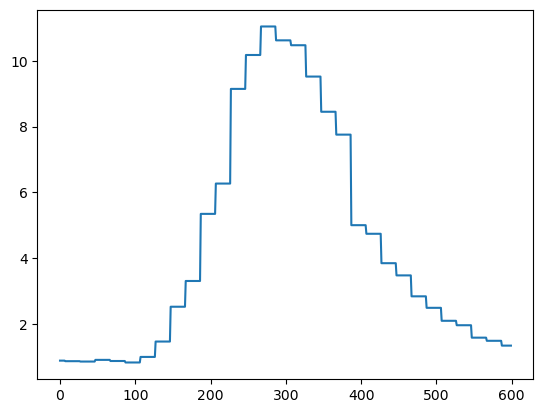

In [16]:
temp = gs_df_regulated.iloc[2]
chrom = temp['chrom']
start = temp['chromStart']
end = temp['chromEnd']
track = k562[chrom][0,start-50:end+50]

plt.plot(track) #isthese 2 big peaks

In [ ]:
temp #need the name of FTL protein in ENSG. ENSG00000087086

dataset                                              FlowFISH_K562
chrom                                                        chr19
chromStart                                                48963708
chromEnd                                                  48964208
name                                 FTL|chr19:49466965-49467465:*
EffectSize                                               -0.900693
chrTSS                                                       chr19
startTSS                                                48965301.0
endTSS                                                  48965302.0
measuredGeneSymbol                                             FTL
Significant                                                   True
pValueAdjusted                                                 0.0
PowerAtEffectSize25                                            1.0
ValidConnection                                               True
CellType                                                      

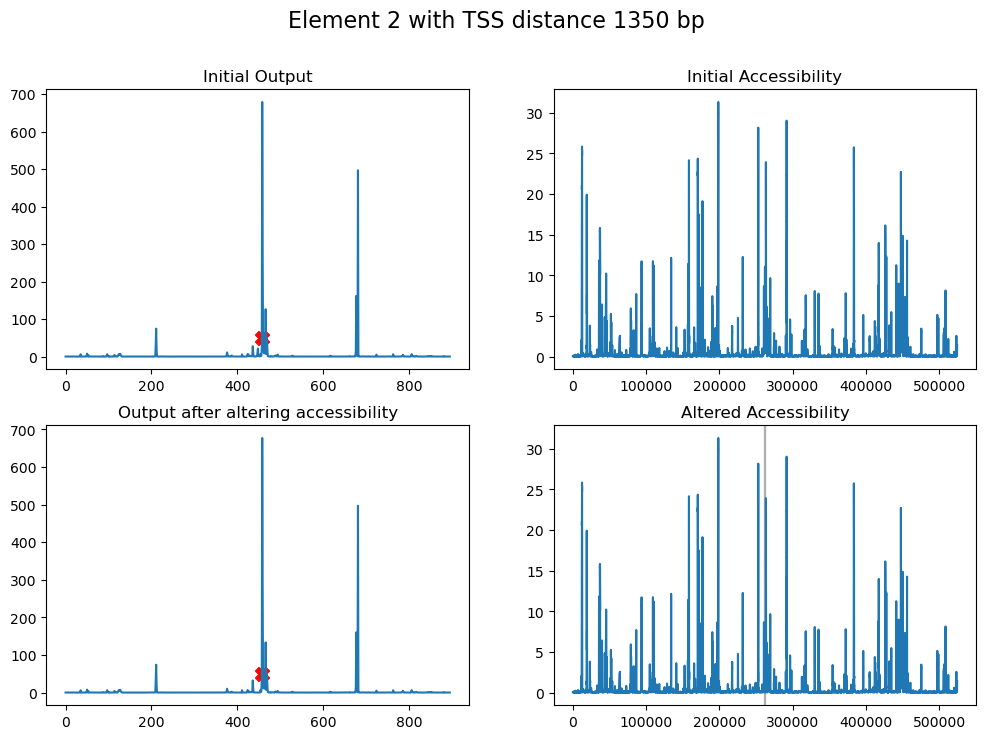

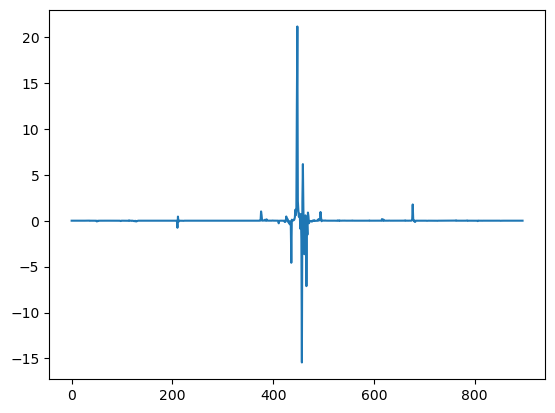

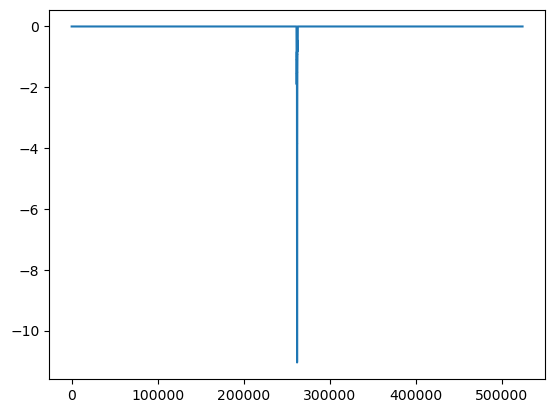

In [31]:
#now let's see idx 3

idx_gs = 2
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
temp_tss = tss_dict['ENSG00000087086']['tss'] #this part of converting to ENSG needs to be done!
diff = temp_tss - mid

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))

plt.suptitle(f"Element {idx_gs} with TSS distance {diff} bp", fontsize=16)

plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1.cpu().numpy().squeeze())
plt.scatter(896//2 + diff//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = 700
acc_copy = acc.clone()
acc_copy[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc_copy), (seq_unmask, acc_unmask)))

plt.plot(out2.cpu().numpy().squeeze())
plt.scatter(896//2 + diff//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc_copy[0].cpu().numpy())
#and make a gray background in the region that was altered
plt.axvspan(mid_acc-dist, mid_acc+dist, color='gray', alpha=0.5)
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.show()
plt.plot(acc_copy[0].cpu().numpy()-acc[0].cpu().numpy())

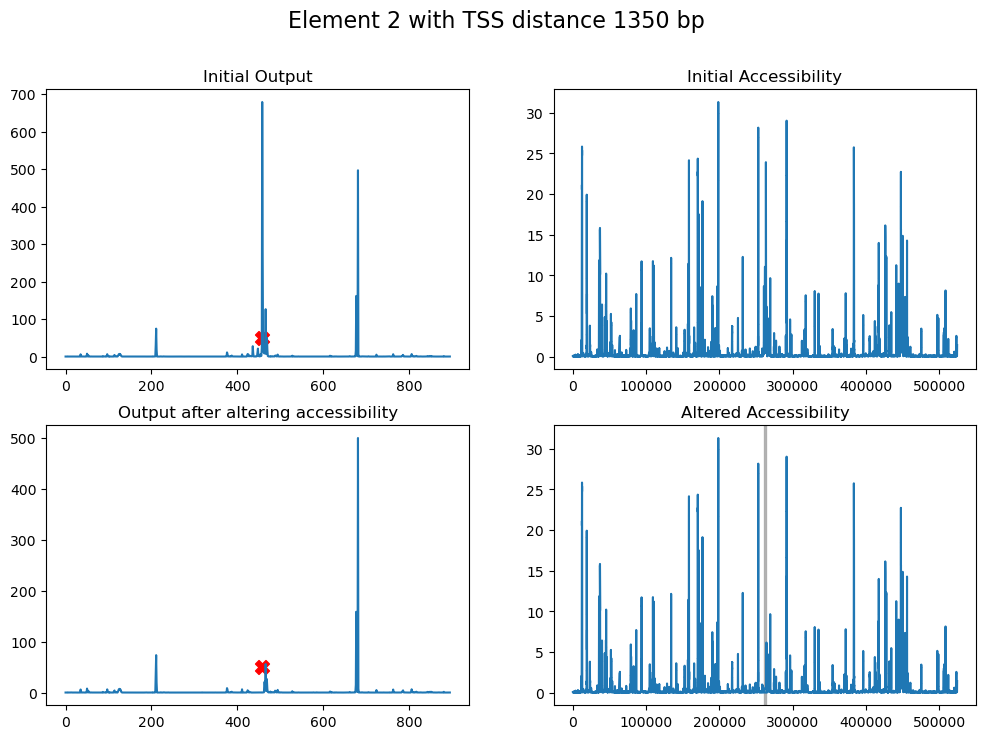

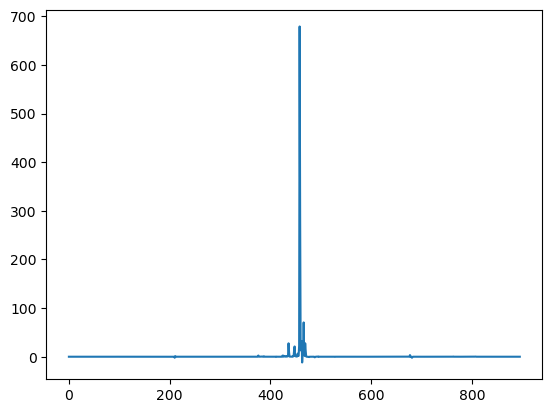

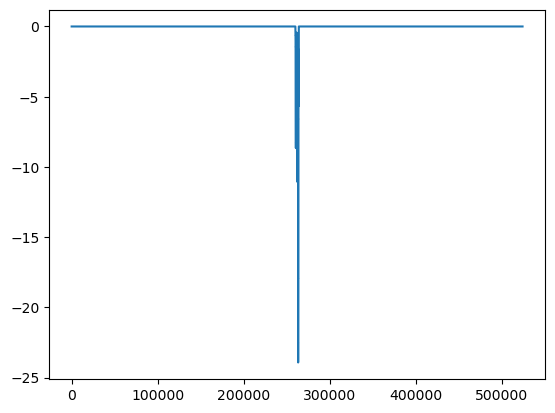

In [32]:
#now let's see idx 3

idx_gs = 2
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
temp_tss = tss_dict['ENSG00000087086']['tss'] #this part of converting to ENSG needs to be done!
diff = temp_tss - mid

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))

plt.suptitle(f"Element {idx_gs} with TSS distance {diff} bp", fontsize=16)

plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1.cpu().numpy().squeeze())
plt.scatter(896//2 + diff//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = 2000
acc_copy = acc.clone()
acc_copy[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc_copy), (seq_unmask, acc_unmask)))

plt.plot(out2.cpu().numpy().squeeze())
plt.scatter(896//2 + diff//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc_copy[0].cpu().numpy())
#and make a gray background in the region that was altered
plt.axvspan(mid_acc-dist, mid_acc+dist, color='gray', alpha=0.5)
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.show()
plt.plot(acc_copy[0].cpu().numpy()-acc[0].cpu().numpy())

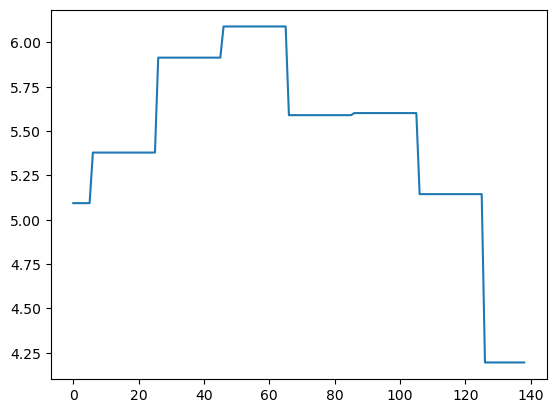

In [33]:
#might be underutilizing enhancers...
#let's now look at idx 1

temp = gs_df_regulated.iloc[1]
chrom = temp['chrom']
start = temp['chromStart']
end = temp['chromEnd']
track = k562[chrom][0,start-50:end+50]

plt.plot(track) #isthese 2 big peaks

In [ ]:
temp #very small peak

dataset                                               FlowFISH_K562
chrom                                                          chrX
chromStart                                                 55028229
chromEnd                                                   55028268
name                                 ALAS2|chrX:55054662-55054701:*
EffectSize                                                    -0.93
chrTSS                                                         chrX
startTSS                                                 55031063.0
endTSS                                                   55031064.0
measuredGeneSymbol                                            ALAS2
Significant                                                    True
pValueAdjusted                                                  NaN
PowerAtEffectSize25                                        0.999983
ValidConnection                                                True
CellType                                        

In [ ]:
#here it's ALAS2 gene

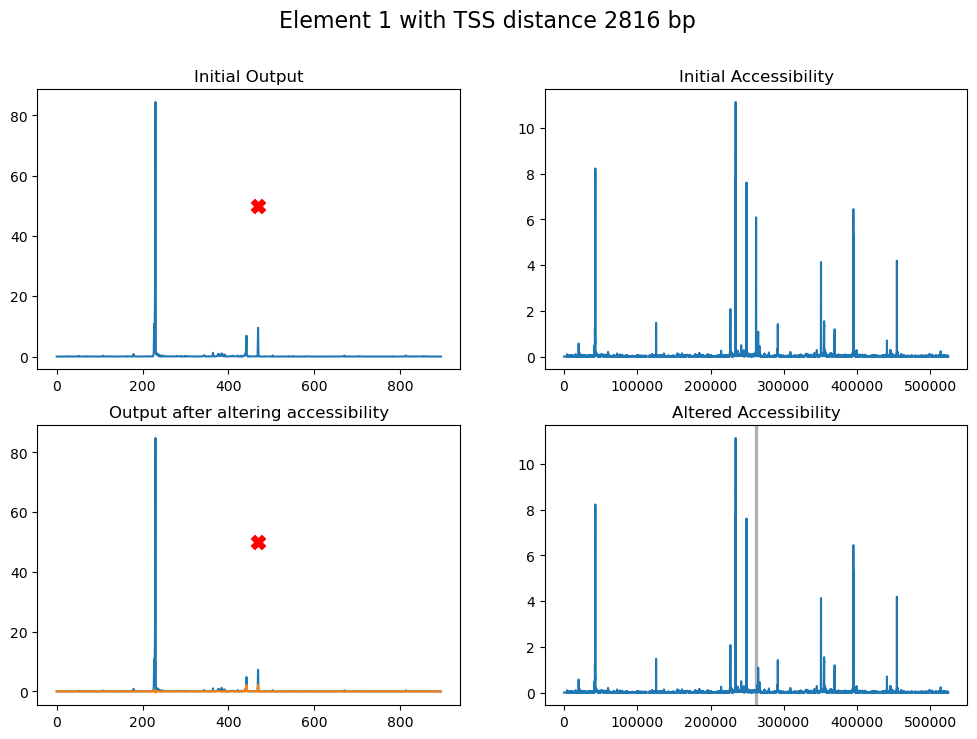

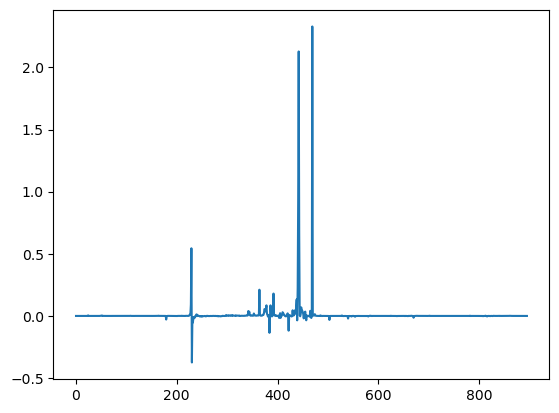

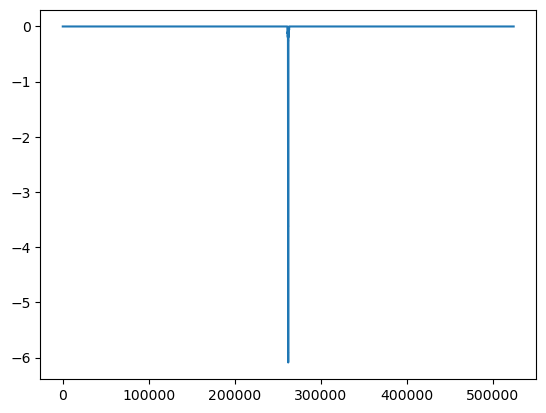

In [37]:
#now let's see idx 3

idx_gs = 1
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
temp_tss = tss_dict['ENSG00000158578']['tss'] #this part of converting to ENSG needs to be done!
diff = temp_tss - mid

#now load in the data
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
#now get the data
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
#and get output
out1 = evals(data=((seq,acc), (seq_unmask, acc_unmask)))


#now we do a 2x2 plot, top 2 are the initial output and initial ack

plt.figure(figsize=(12,8))

plt.suptitle(f"Element {idx_gs} with TSS distance {diff} bp", fontsize=16)

plt.subplot(2,2,1)
plt.title("Initial Output")
plt.plot(out1.cpu().numpy().squeeze())
plt.scatter(896//2 + diff//128, 50, color='r', marker='X', s=100)
plt.subplot(2,2,2)
plt.title("Initial Accessibility")
plt.plot(acc[0].cpu().numpy())
plt.subplot(2,2,3)
plt.title("Output after altering accessibility")


#now alter accessibility and see new output
mid_acc = acc.shape[1]//2
dist = 1000
acc_copy = acc.clone()
acc_copy[0,mid_acc-dist:mid_acc+dist] = acc[0,mid_acc-dist:mid_acc+dist]//100 #reduce by 100
# acc[0]=acc[0]/2
out2 = evals(data=((seq,acc_copy), (seq_unmask, acc_unmask)))

plt.plot(out2.cpu().numpy().squeeze())
plt.scatter(896//2 + diff//128, 50, color='r', marker='X', s=100)
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.subplot(2,2,4)
plt.title("Altered Accessibility")
plt.plot(acc_copy[0].cpu().numpy())
#and make a gray background in the region that was altered
plt.axvspan(mid_acc-dist, mid_acc+dist, color='gray', alpha=0.5)
#clealry uses the information!! This is really good to see
plt.show()

#now plot the difference
plt.plot((out1-out2).cpu().numpy().squeeze())
plt.show()
plt.plot(acc_copy[0].cpu().numpy()-acc[0].cpu().numpy())

In [ ]:
#let's also make sure it is using the k562 file so we odn't have to load that separately
evals.cfg['dataset'] #yeah that's the same one, perfect, we can easily load and edit the peak!

{'data_path': '/data1/lesliec/sarthak/data/DK_zarr/zarr_arrays/cell_type_arrays/K562_DNase.npz',
 'length': 524288,
 'shift_sequences': 0,
 'load_in': False,
 'rc_aug': False,
 'mlm': 0,
 'acc_mlm': 0,
 'acc_type': 'continuous',
 'acc_mask_size': 500,
 'weight_peaks': False,
 'additional_data': '/data1/lesliec/sarthak/data/enformer/data/labels.zarr',
 'sequences_bed_file': '/data1/lesliec/sarthak/data/DK_zarr/sequences_enformer.bed',
 'additional_data_idxs': 5111,
 'split': 'test',
 'evaluating': True}

# genome wide
slowdown is dataloading. Can manually set additional_data to false so it doens't load the CAGE data at all but then can set load in True for fast speedups

other thing is convering to ENSG ID

Final thing is deciding how far away to silence enhancer and how far away from main TSS to measure signal change. Should alt TSS information be used too?

maybe just do enhancer +/- 100 bp to silence



In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t")

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

gs_df_regulated = gs_df[gs_df["Regulated"] == True] #487
#now sort it by absolute value of EffectSize column
gs_df_regulated = gs_df_regulated.reindex(gs_df_regulated["EffectSize"].abs().sort_values(ascending=False).index)

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)

In [16]:
tss

,#chr,start,end,name,score,strand,Ensembl_ID,gene_type
0,chr1,35831,36331,FAM138A,0,-,ENSG00000237613,lincRNA
1,chr1,35831,36331,FAM138F,0,-,ENSG00000282591,lincRNA
2,chr1,68840,69340,OR4F5,0,+,ENSG00000186092,protein_coding
3,chr1,817120,817620,FAM87B,0,+,ENSG00000177757,lincRNA
4,chr1,827272,827772,LINC00115,0,-,ENSG00000225880,lincRNA
...,...,...,...,...,...,...,...,...
20662,chrY,21386110,21386610,PRORY,0,-,ENSG00000183146,protein_coding
20663,chrY,21594416,21594916,TTTY13,0,-,ENSG00000184991,lincRNA
20664,chrY,22298626,22299126,TTTY5,0,-,ENSG00000215560,lincRNA
20665,chrY,23198842,23199342,DAZ1,0,-,ENSG00000188120,protein_coding


In [17]:
#create mapping from name to ensemble id
# genes = tss['name'].unique().tolist()
# len(genes), len(tss). All  unique
# tss
#just create dict mapping from name to ensemble id
name_to_ensg = {}
for idx, row in tss.iterrows():
    name = row['name']
    ensg = row['Ensembl_ID']
    name_to_ensg[name] = ensg
name_to_ensg

{'FAM138A': 'ENSG00000237613',
 'FAM138F': 'ENSG00000282591',
 'OR4F5': 'ENSG00000186092',
 'FAM87B': 'ENSG00000177757',
 'LINC00115': 'ENSG00000225880',
 'LINC01128': 'ENSG00000228794',
 'FAM41C': 'ENSG00000230368',
 'SAMD11': 'ENSG00000187634',
 'NOC2L': 'ENSG00000188976',
 'KLHL17': 'ENSG00000187961',
 'PLEKHN1': 'ENSG00000187583',
 'PERM1': 'ENSG00000187642',
 'HES4': 'ENSG00000188290',
 'ISG15': 'ENSG00000187608',
 'AGRN': 'ENSG00000188157',
 'RNF223': 'ENSG00000237330',
 'C1orf159': 'ENSG00000131591',
 'LINC01342': 'ENSG00000223823',
 'TTLL10': 'ENSG00000162571',
 'TNFRSF18': 'ENSG00000186891',
 'TNFRSF4': 'ENSG00000186827',
 'SDF4': 'ENSG00000078808',
 'B3GALT6': 'ENSG00000176022',
 'C1QTNF12': 'ENSG00000184163',
 'UBE2J2': 'ENSG00000160087',
 'SCNN1D': 'ENSG00000162572',
 'ACAP3': 'ENSG00000131584',
 'PUSL1': 'ENSG00000169972',
 'INTS11': 'ENSG00000127054',
 'CPTP': 'ENSG00000224051',
 'TAS1R3': 'ENSG00000169962',
 'DVL1': 'ENSG00000107404',
 'MXRA8': 'ENSG00000162576',
 'AURKA

In [21]:
#now ensure that it maps all of them
unlabeled_genes = []
genes = gs_df['measuredGeneSymbol'].unique().tolist()
for gene in genes:
    if gene not in name_to_ensg:
        unlabeled_genes.append(gene)
        print(f"{gene} not in name_to_ensg")

RP4-798A10.7 not in name_to_ensg
RP1-18D14.7 not in name_to_ensg
RP11-85G21.3 not in name_to_ensg
KCNQ1OT1 not in name_to_ensg
RP11-620J15.3 not in name_to_ensg
MLXIP not in name_to_ensg
WASH4P not in name_to_ensg
CTD-2576D5.4 not in name_to_ensg
RP11-20B24.2 not in name_to_ensg
RP11-498C9.15 not in name_to_ensg
GLTSCR2 not in name_to_ensg
AC016723.4 not in name_to_ensg
ZFAS1 not in name_to_ensg
LINC00659 not in name_to_ensg
UFD1L not in name_to_ensg
FGD5-AS1 not in name_to_ensg
RP11-424N24.2 not in name_to_ensg
GATA2-AS1 not in name_to_ensg
AC093323.3 not in name_to_ensg
RP11-328K4.1 not in name_to_ensg
NNT-AS1 not in name_to_ensg
CTD-2366F13.1 not in name_to_ensg
RP1-40E16.9 not in name_to_ensg
ZSCAN16-AS1 not in name_to_ensg
HCG18 not in name_to_ensg
STK19 not in name_to_ensg
RP3-460G2.2 not in name_to_ensg
AC002480.3 not in name_to_ensg
AC073072.5 not in name_to_ensg
WBSCR22 not in name_to_ensg
CTA-392E5.1 not in name_to_ensg
RP11-809O17.1 not in name_to_ensg
RP6-159A1.3 not in nam

In [22]:
unlabeled_genes

['RP4-798A10.7',
 'RP1-18D14.7',
 'RP11-85G21.3',
 'KCNQ1OT1',
 'RP11-620J15.3',
 'MLXIP',
 'WASH4P',
 'CTD-2576D5.4',
 'RP11-20B24.2',
 'RP11-498C9.15',
 'GLTSCR2',
 'AC016723.4',
 'ZFAS1',
 'LINC00659',
 'UFD1L',
 'FGD5-AS1',
 'RP11-424N24.2',
 'GATA2-AS1',
 'AC093323.3',
 'RP11-328K4.1',
 'NNT-AS1',
 'CTD-2366F13.1',
 'RP1-40E16.9',
 'ZSCAN16-AS1',
 'HCG18',
 'STK19',
 'RP3-460G2.2',
 'AC002480.3',
 'AC073072.5',
 'WBSCR22',
 'CTA-392E5.1',
 'RP11-809O17.1',
 'RP6-159A1.3']

In [ ]:
#let's exclude the ones that we can't map? Let's see if we can find what they are at least?
#just 33 out of 2k+ genes!
#27 of them not in the mygene either, so best to just exclude these


# now figuring out CAGE indexing

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t")

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

gs_df_regulated = gs_df[gs_df["Regulated"] == True] #487
#now sort it by absolute value of EffectSize column
gs_df_regulated = gs_df_regulated.reindex(gs_df_regulated["EffectSize"].abs().sort_values(ascending=False).index)

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)
    
name_to_ensg = tss.set_index('name')['Ensembl_ID'].to_dict()

In [2]:
#and the evals dataset
import sys
sys.path.append('/data1/lesliec/sarthak/caduceus/')
import torch
from tqdm import tqdm
from src.dataloaders.datasets.general_dataset import GeneralDataset
from src.models.sequence.dna_embedding import DNAEmbeddingModelCaduceus
from src.tasks.decoders import EnformerDecoder
from src.tasks.encoders import JointCNN
from caduceus.configuration_caduceus import CaduceusConfig
import yaml
from omegaconf import OmegaConf
import os
import itertools
import inspect
try:
    OmegaConf.register_new_resolver('eval', eval)
    OmegaConf.register_new_resolver('div_up', lambda x, y: (x + y - 1) // y)
except ValueError as e:
    if "Resolver already registered" in str(e):
            print("Resolver already exists, skipping registration.")

# from evals_utils_joint import Evals
class Evals():
    def __init__(self,
                 ckpt_path,
                 dataset=None,
                 split = 'test',
                 device = None,
                 load_data=False,
                 **dataset_overrides #Don't pass None into overrides unless you intentionally want it to be None! Pass in items only that you need
                 ) -> None:
        
        #now load the cfg from the checkpoint path
        model_cfg_path = os.path.join(os.path.dirname(os.path.dirname(ckpt_path)), '.hydra', 'config.yaml')
        cfg = yaml.load(open(model_cfg_path, 'r'), Loader=yaml.FullLoader)
        cfg = OmegaConf.create(cfg)
        self.cfg = OmegaConf.to_container(cfg, resolve=True)
        
        state_dict = torch.load(ckpt_path, map_location='cpu')
        if device is not None:
            #if we are given a device, we will use that device
            self.device = torch.device(device)
        else:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.split = split

        #now set up dataset
        if dataset is None:
            dataset_args = self.cfg['dataset']
            assert dataset_args['mlm'] == 0 and dataset_args['acc_mlm'] == 0, "MLM and acc_mlm should be 0 for the training"
            sig = inspect.signature(GeneralDataset.__init__)
            sig = {k: v for k, v in sig.parameters.items() if k != 'self'}
            to_remove = []
            for k, v in dataset_args.items():
                if k not in sig:
                    # del dataset_args[k]
                    to_remove.append(k)
            for k in to_remove:
                del dataset_args[k]
            dataset_args['split'] = split
            dataset_args['evaluating'] = True #this tells it to not do things like random shifting and rc aug, still does random masking tho, can get og sequence easily
            dataset_args['load_in'] = load_data
            dataset_args['additional_data'] = None #override so we can load the dataset!
            
            for k, v in dataset_overrides.items():
                if k in sig:
                    dataset_args[k] = v
                    print(f"Overriding {k} with {v}")
                else:
                    print(f"Warning: {k} not in dataset args, skipping")
            
            # dataset_args['rc_aug'] = False #we don't want to do rc aug in our evaluation class!!!
            self.dataset_args = dataset_args
            # self.dataset_args['rc_aug'] = False #we don't want to do rc aug in our evaluation class!!!
            self.dataset = GeneralDataset(**dataset_args)
            
            # self.kmer_len = dataset_args['kmer_len']
            # self.dataset = enformer_dataset.EnformerDataset(split, dataset_args['max_length'], rc_aug = dataset_args['rc_aug'],
            #                                                 return_CAGE=dataset_args['return_CAGE'], cell_type=dataset_args.get('cell_type', None),
            #                                                 kmer_len=dataset_args['kmer_len']) #could use dataloader instead, but again kinda complex
        else:
            self.dataset = dataset
         
        torch.nn.modules.utils.consume_prefix_in_state_dict_if_present(
            state_dict["state_dict"], "model."
        )
        model_state_dict = state_dict["state_dict"]
        # need to remove torchmetrics. to remove keys, need to convert to list first
        for key in list(model_state_dict.keys()):
            if "torchmetrics" in key:
                model_state_dict.pop(key)
        # the state_dict keys slightly mismatch from Lightning..., so we fix it here
        decoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "decoder" in key:
                decoder_state_dict[key[10:]] = model_state_dict.pop(key)
        encoder_state_dict = {}
        for key in list(model_state_dict.keys()):
            if "encoder" in key:
                encoder_state_dict[key[10:]] = model_state_dict.pop(key)
        
        cfg['model']['config'].pop('_target_')
        # cfg['model']['config']['complement_map'] = self.dataset.tokenizer.complement_map
        caduceus_cfg = CaduceusConfig(**cfg['model']['config'])
        
        self.backbone = DNAEmbeddingModelCaduceus(config=caduceus_cfg)
        self.backbone.load_state_dict(model_state_dict, strict=True)
        
        #remove self.cfg['decoder']['_name_']
        del self.cfg['decoder']['_name_']
        self.cfg['decoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.decoder = EnformerDecoder(**self.cfg['decoder']) #could do with instantiating, but that is rather complex
        self.decoder.load_state_dict(decoder_state_dict, strict=True)
        
        del self.cfg['encoder']['_name_']
        self.cfg['encoder']['d_model'] = self.cfg['model']['config']['d_model']
        self.encoder = JointCNN(**self.cfg['encoder'])
        self.encoder.load_state_dict(encoder_state_dict, strict=True)
        
        self.encoder.to(self.device).eval()
        self.backbone.to(self.device).eval()
        self.decoder.to(self.device).eval()
        
    def __call__(self, idx=None, data=None):
        #now evaluate the model on one example
        if data is None:
            (seq,acc),_ = self.dataset[idx]
            
            x = seq.unsqueeze(0)
            y = acc.unsqueeze(0)
        else:
            (x,y),_ = data

            if x.dim() == 2:
                x = x.unsqueeze(0) #add batch dim
                y = y.unsqueeze(0) #add batch dim
        
        x,y = x.to(self.device), y.to(self.device)
        
        with torch.no_grad():
            x1,_ = self.encoder(x,y)
            x1,_ = self.backbone(x1)
            x1 = self.decoder(x1)
        
        return x1

#this is the model that was trained on unstranded cage at 128 bp resolution. Let's see if it even predicts these values!
ckpt_path = '/data1/lesliec/sarthak/caduceus/outputs/2025-08-15/12-23-01-318424/checkpoints/last.ckpt'
evals = Evals(ckpt_path,load_data=True, device=0)

#first we have to see the prediction of this region, then extend the dataset

JointMaskingEncoder: d_model=256, celltypes=None, d_input1=6, d_input2=None, joint=False, kernel_size=15, combine=True, acc_type=continuous
Using norm: seq=<class 'torch.nn.modules.linear.Identity'>, rest=<class 'torch.nn.modules.linear.Identity'>


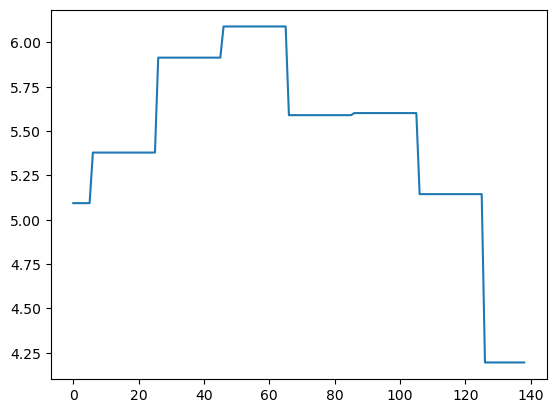

In [24]:
temp = gs_df_regulated.iloc[1]
chrom = temp['chrom']
start = temp['chromStart']
end = temp['chromEnd']
track = evals.dataset.data[chrom][0,start-50:end+50]

plt.plot(track) #isthese 2 big peaks

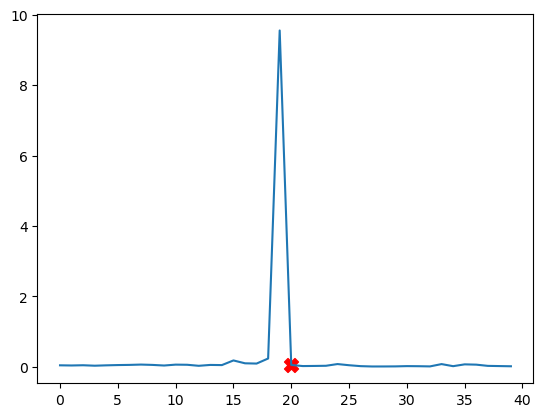

In [29]:
#yeah same thing, so no need to load k562

#now let's make sure cage logic makes sense and that the bins align

idx_gs = 1
element = gs_df_regulated.iloc[idx_gs]
#now tss info
mid = (element['chromEnd']+element['chromStart'])//2
chrom = element['chrom']
ensgid = name_to_ensg[element['measuredGeneSymbol']]
temp_tss = tss_dict[ensgid]['tss'] #this part of converting to ENSG needs to be done!
# temp_tss = tss_dict['ENSG00000158578']['tss'] #this part of converting to ENSG needs to be done!
diff = temp_tss - mid

gene_location = 896//2 + diff//128

#now get prediction of the model on this region
idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
(seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
out = evals(data=((seq,acc), (seq_unmask, acc_unmask))).cpu().numpy().squeeze()

dist_to_look = 20
plt.plot(out[gene_location-dist_to_look:gene_location+dist_to_look]) #let's just look at the region around the gene, does it have a peak there?
plt.scatter(dist_to_look, out[gene_location], color='r', marker='X', s=100)

Skipping BTG1 because TSS is too far from the element
Skipping RP3-460G2.2 because it is not in the name_to_ensg mapping
Skipping PICALM because TSS is too far from the element
Skipping MYC because TSS is too far from the element
Skipping CCND2 because TSS is too far from the element
Skipping PICALM because TSS is too far from the element
Skipping BTG1 because TSS is too far from the element


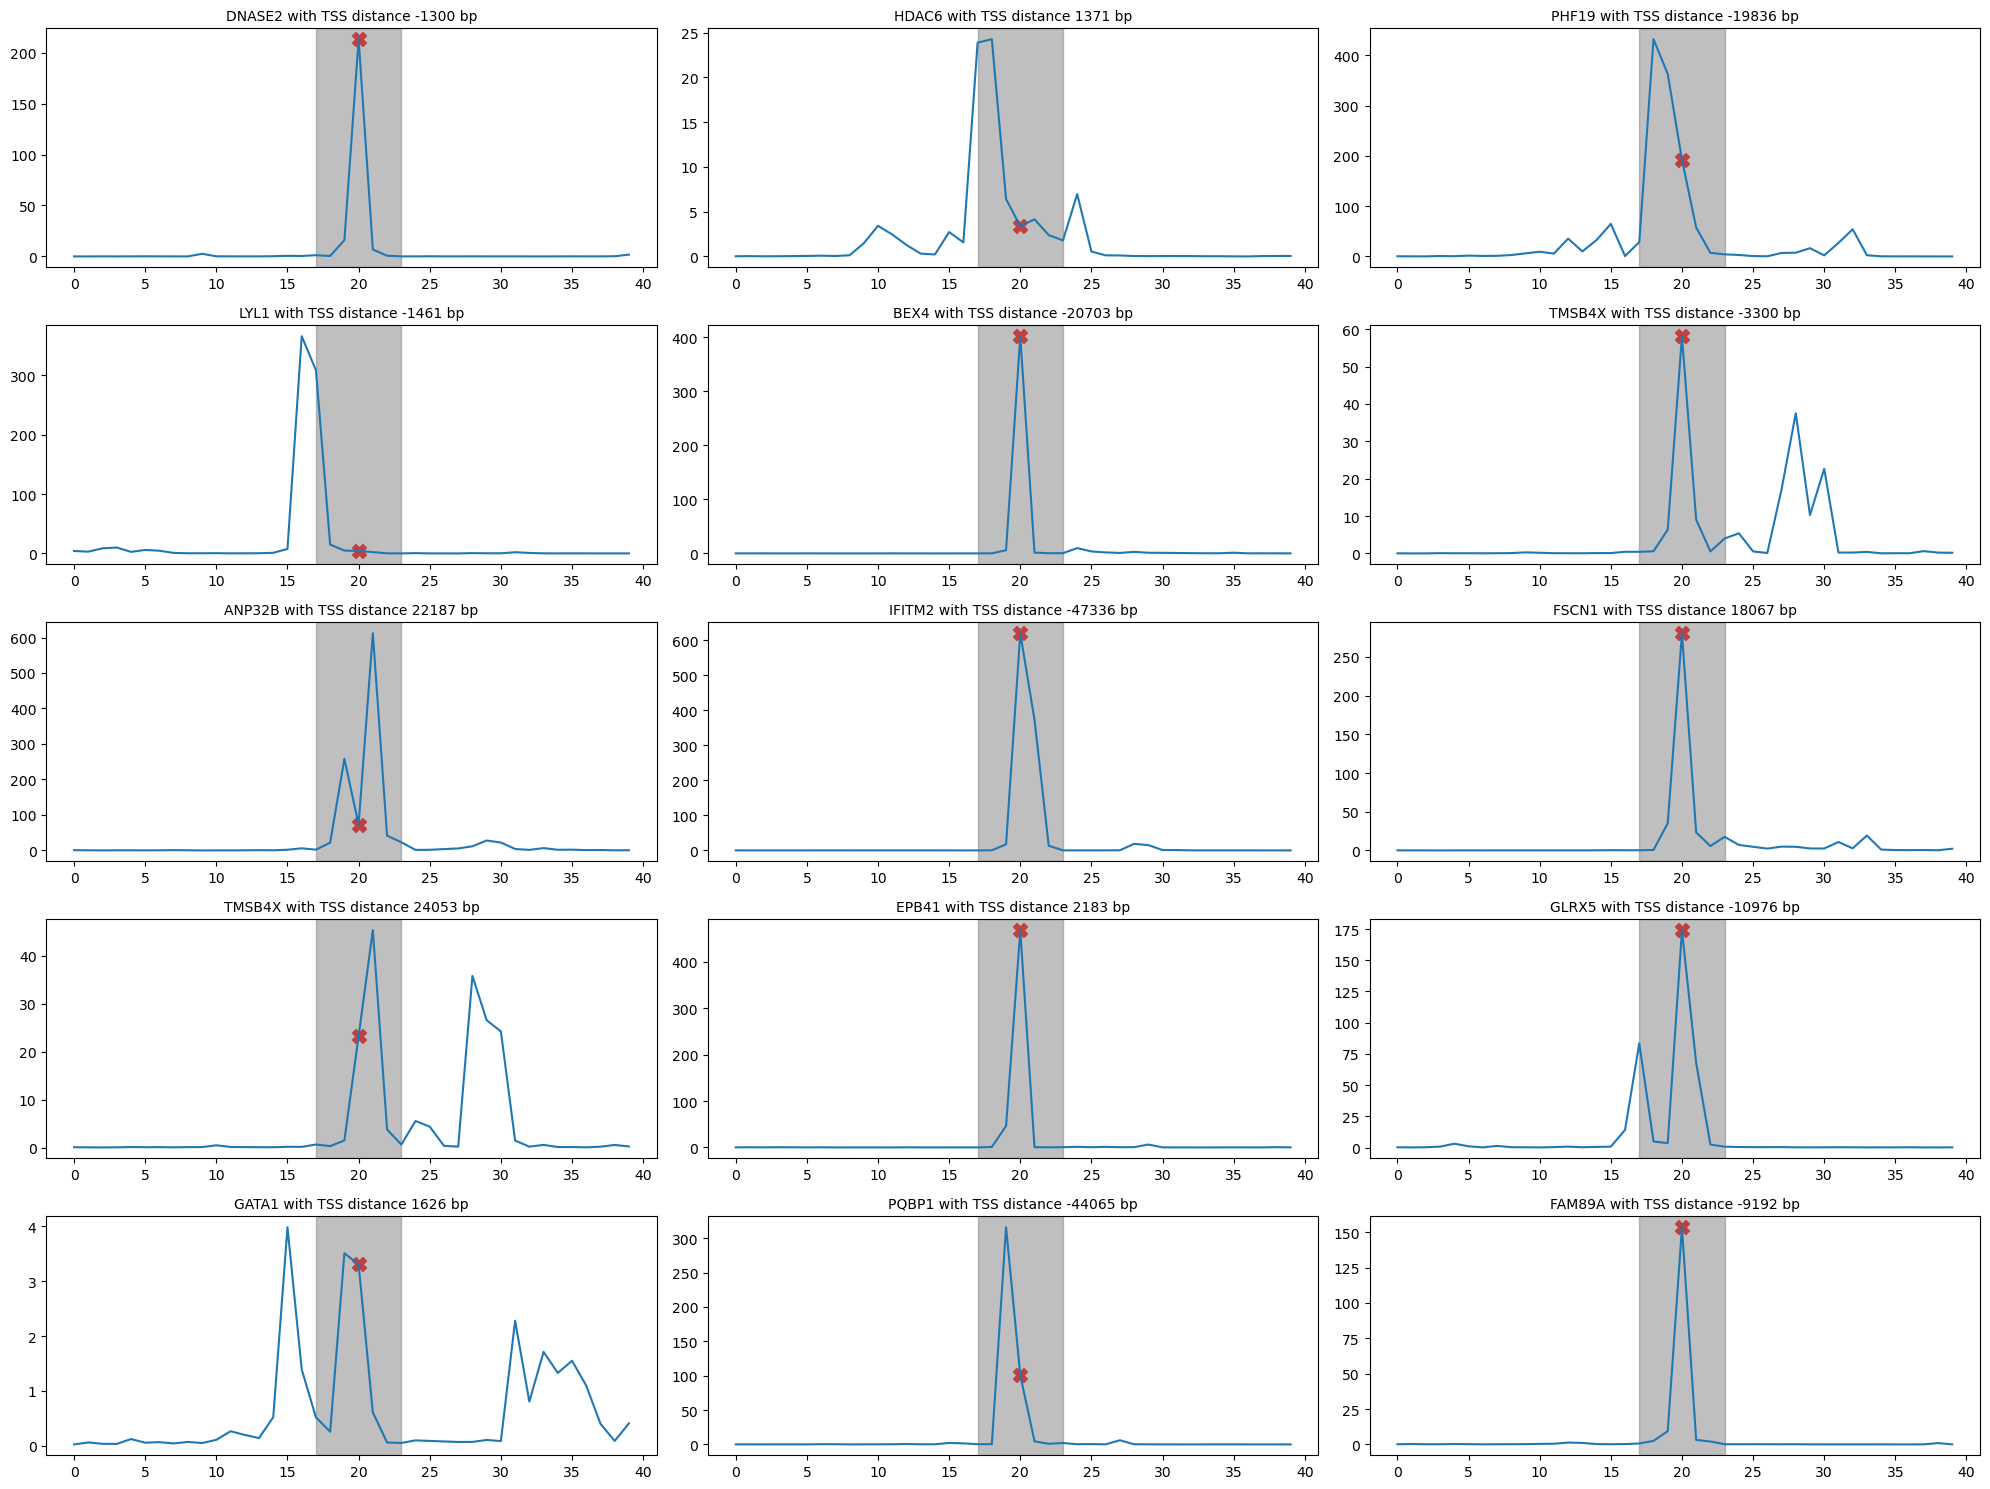

In [38]:
#let's plot this for roughly 15 genes in a 5x3 grid
plt.figure(figsize=(20,15))
i = 100
plot_idx = 1
while plot_idx < 16 and i < len(gs_df_regulated):
    idx_gs = i
    element = gs_df_regulated.iloc[idx_gs]
    #now tss info
    mid = (element['chromEnd']+element['chromStart'])//2
    chrom = element['chrom']
    ensgid = name_to_ensg.get(element['measuredGeneSymbol'], None)
    if ensgid is None:
        print(f"Skipping {element['measuredGeneSymbol']} because it is not in the name_to_ensg mapping")
        i += 1
        continue
    temp_tss = tss_dict[ensgid]['tss'] #this part of converting to ENSG needs to be done!
    diff = temp_tss - mid
    if abs(diff) > 896//2*128: #if the tss is outside of the region we are looking at, then we can't really say much about it, so we skip it
        print(f"Skipping {element['measuredGeneSymbol']} because TSS is too far from the element")
        i += 1
        continue

    gene_location = 896//2 + diff//128

    #now get prediction of the model on this region
    idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
    (seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
    out = evals(data=((seq,acc), (seq_unmask, acc_unmask))).cpu().numpy().squeeze()

    dist_to_look = 20
    plt.subplot(5,3,plot_idx)
    plot_idx += 1
    plt.plot(out[gene_location-dist_to_look:gene_location+dist_to_look]) #let's just look at the region around the gene, does it have a peak there?
    plt.scatter(dist_to_look, out[gene_location], color='r', marker='X', s=100)

    #add grey bars up 2 and down 2 of the scatter
    plt.axvspan(dist_to_look-3, dist_to_look+3, color='gray', alpha=0.5)
    
    plt.title(f"{element['measuredGeneSymbol']} with TSS distance {diff} bp", fontsize=10)
    i += 1
plt.tight_layout()
plt.show()

In [39]:
tss_dict[ensgid]

{'chrom': 'chr1',
 'counts': 3.18269229751619,
 'tss': 231040249,
 'alt_tss': [231040254, 231040242, 231040246, 231040223],
 'strand': '-',
 'split': 'train'}

Skipping BTG1 because TSS is too far from the element
Skipping RP3-460G2.2 because it is not in the name_to_ensg mapping
Skipping PICALM because TSS is too far from the element
Skipping MYC because TSS is too far from the element
Skipping CCND2 because TSS is too far from the element
Skipping PICALM because TSS is too far from the element
Skipping BTG1 because TSS is too far from the element


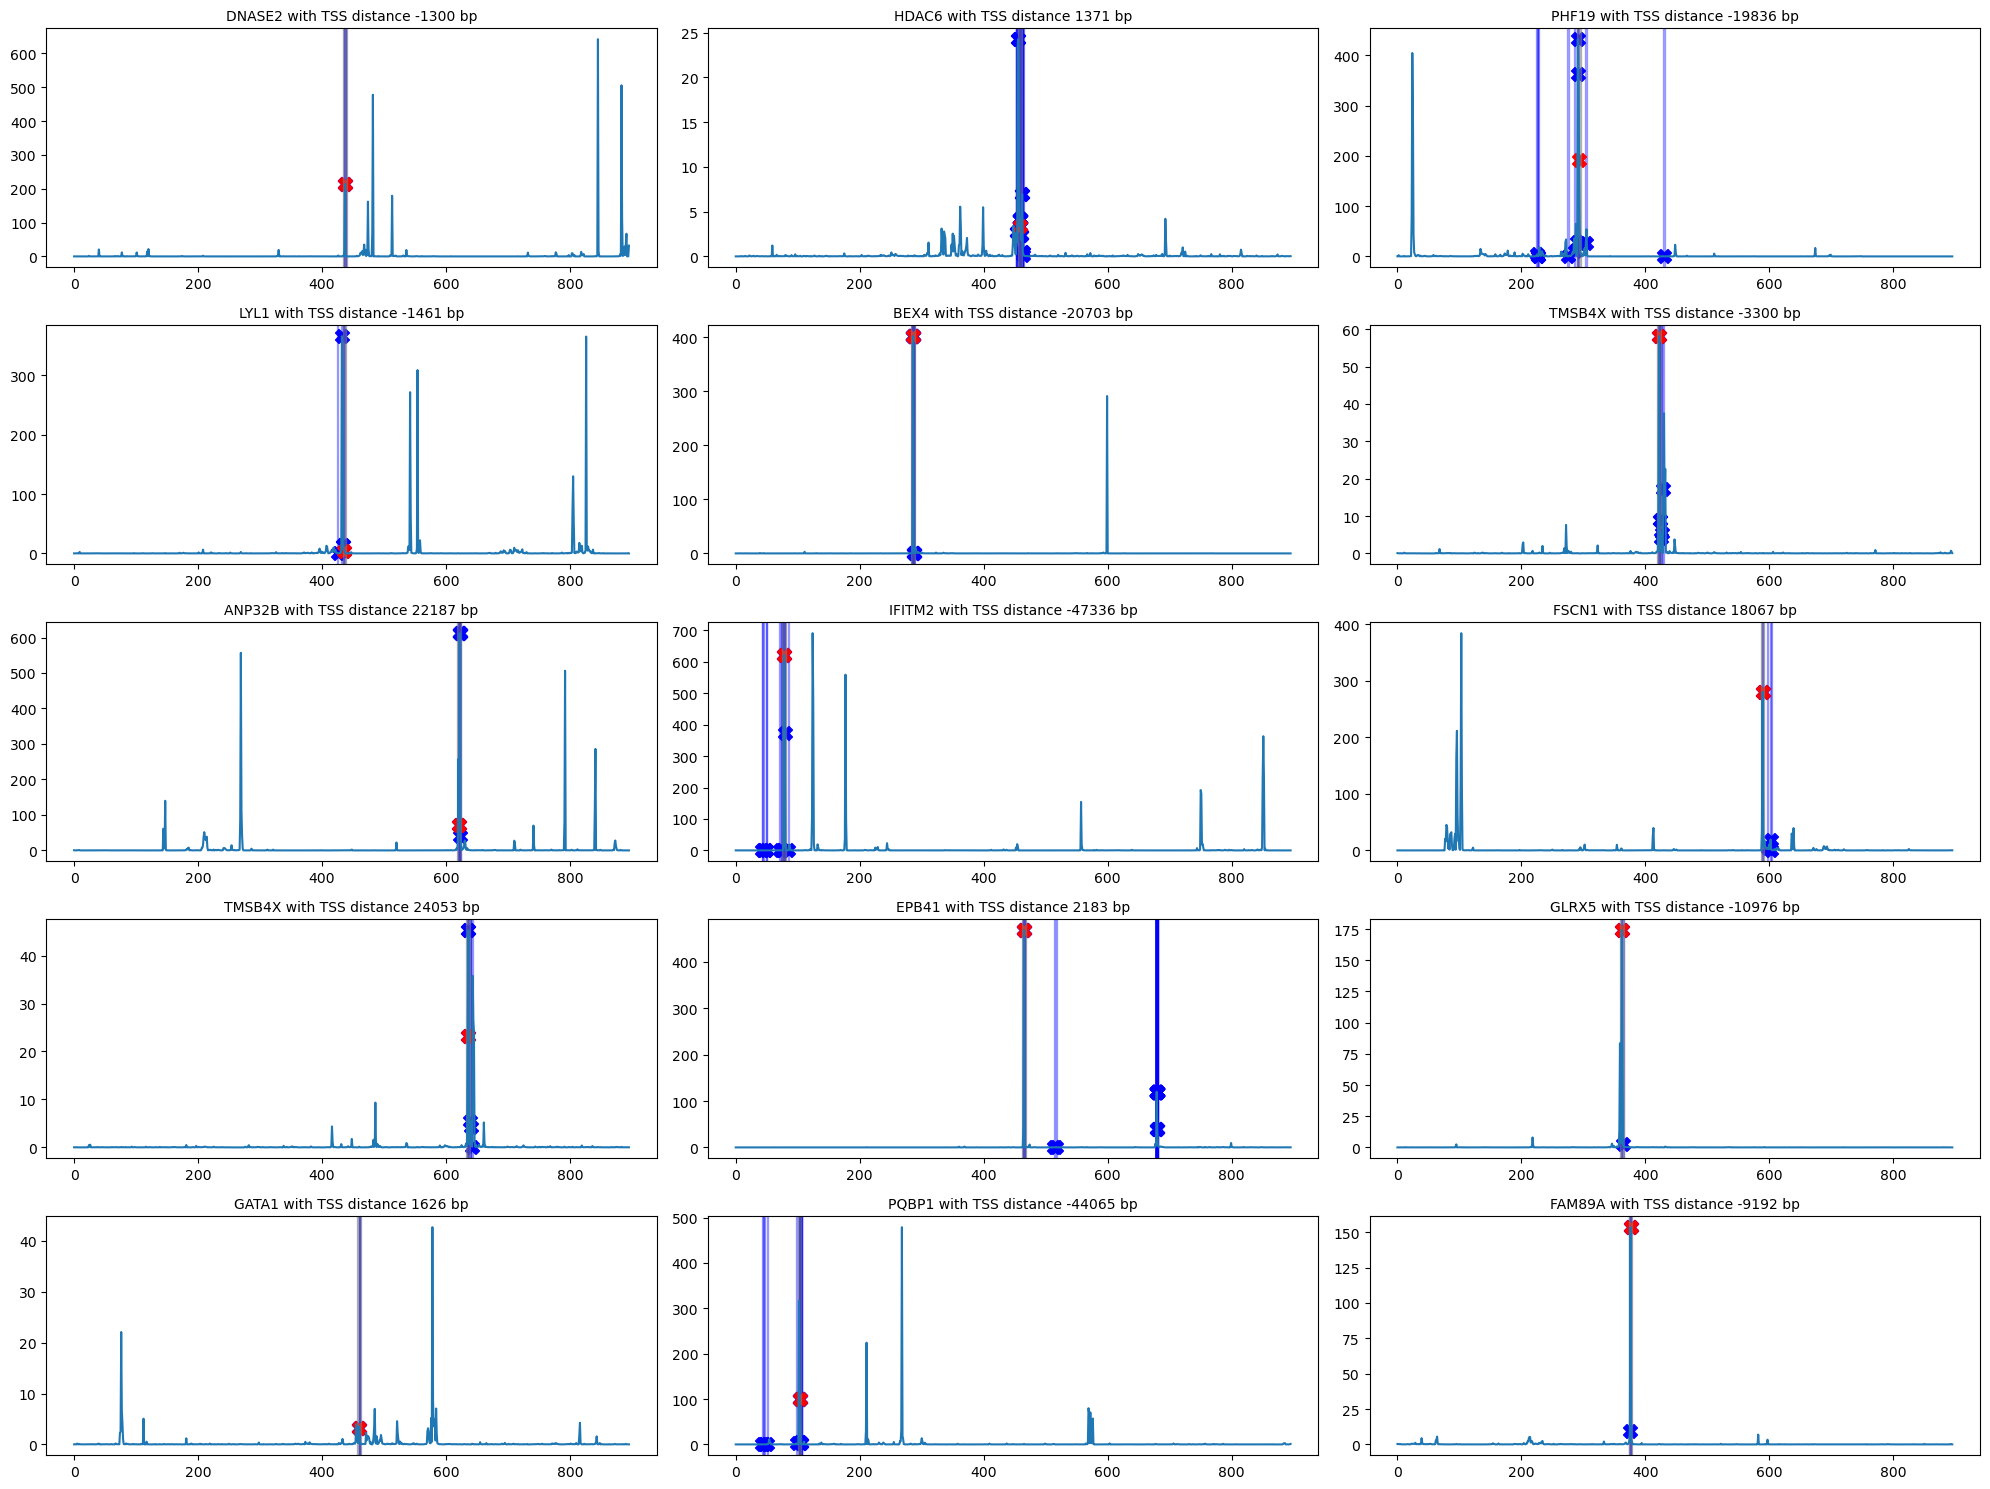

In [40]:
#let's also look at alt promoters
plt.figure(figsize=(20,15))
i = 100
plot_idx = 1
while plot_idx < 16 and i < len(gs_df_regulated):
    idx_gs = i
    element = gs_df_regulated.iloc[idx_gs]
    #now tss info
    mid = (element['chromEnd']+element['chromStart'])//2
    chrom = element['chrom']
    ensgid = name_to_ensg.get(element['measuredGeneSymbol'], None)
    if ensgid is None:
        print(f"Skipping {element['measuredGeneSymbol']} because it is not in the name_to_ensg mapping")
        i += 1
        continue
    temp_tss = tss_dict[ensgid]['tss'] #this part of converting to ENSG needs to be done!
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss #do it relative to the main tss
    diff = temp_tss - mid
    if abs(diff) > 896//2*128: #if the tss is outside of the region we are looking at, then we can't really say much about it, so we skip it
        print(f"Skipping {element['measuredGeneSymbol']} because TSS is too far from the element")
        i += 1
        continue

    gene_location = 896//2 + diff//128

    #now get prediction of the model on this region
    idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
    (seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
    out = evals(data=((seq,acc), (seq_unmask, acc_unmask))).cpu().numpy().squeeze()

    plt.subplot(5,3,plot_idx)
    plot_idx += 1
    plt.plot(out) #let's just look at the region around the gene, does it have a peak there?
    #plot the alt tss as well
    for alt in alt_tss:
        alt_location = 896//2 + (diff + alt)//128
        if 0 <= alt_location < 896: # Crucial crash prevention
            plt.scatter(alt_location, out[alt_location], color='b', marker='X', s=100)
            plt.axvspan(alt_location-1, alt_location+1, color='blue', alpha=0.3)
    plt.scatter(gene_location, out[gene_location], color='r', marker='X', s=100)

    #add grey bars up 2 and down 2 of the scatter
    plt.axvspan(gene_location-3, gene_location+3, color='gray', alpha=0.5)
    
    plt.title(f"{element['measuredGeneSymbol']} with TSS distance {diff} bp", fontsize=10)
    i += 1
plt.tight_layout()
plt.show()

Skipping BTG1 because TSS is too far from the element
Skipping RP3-460G2.2 because it is not in the name_to_ensg mapping
Skipping PICALM because TSS is too far from the element
Skipping MYC because TSS is too far from the element
Skipping CCND2 because TSS is too far from the element
Skipping PICALM because TSS is too far from the element
Skipping BTG1 because TSS is too far from the element


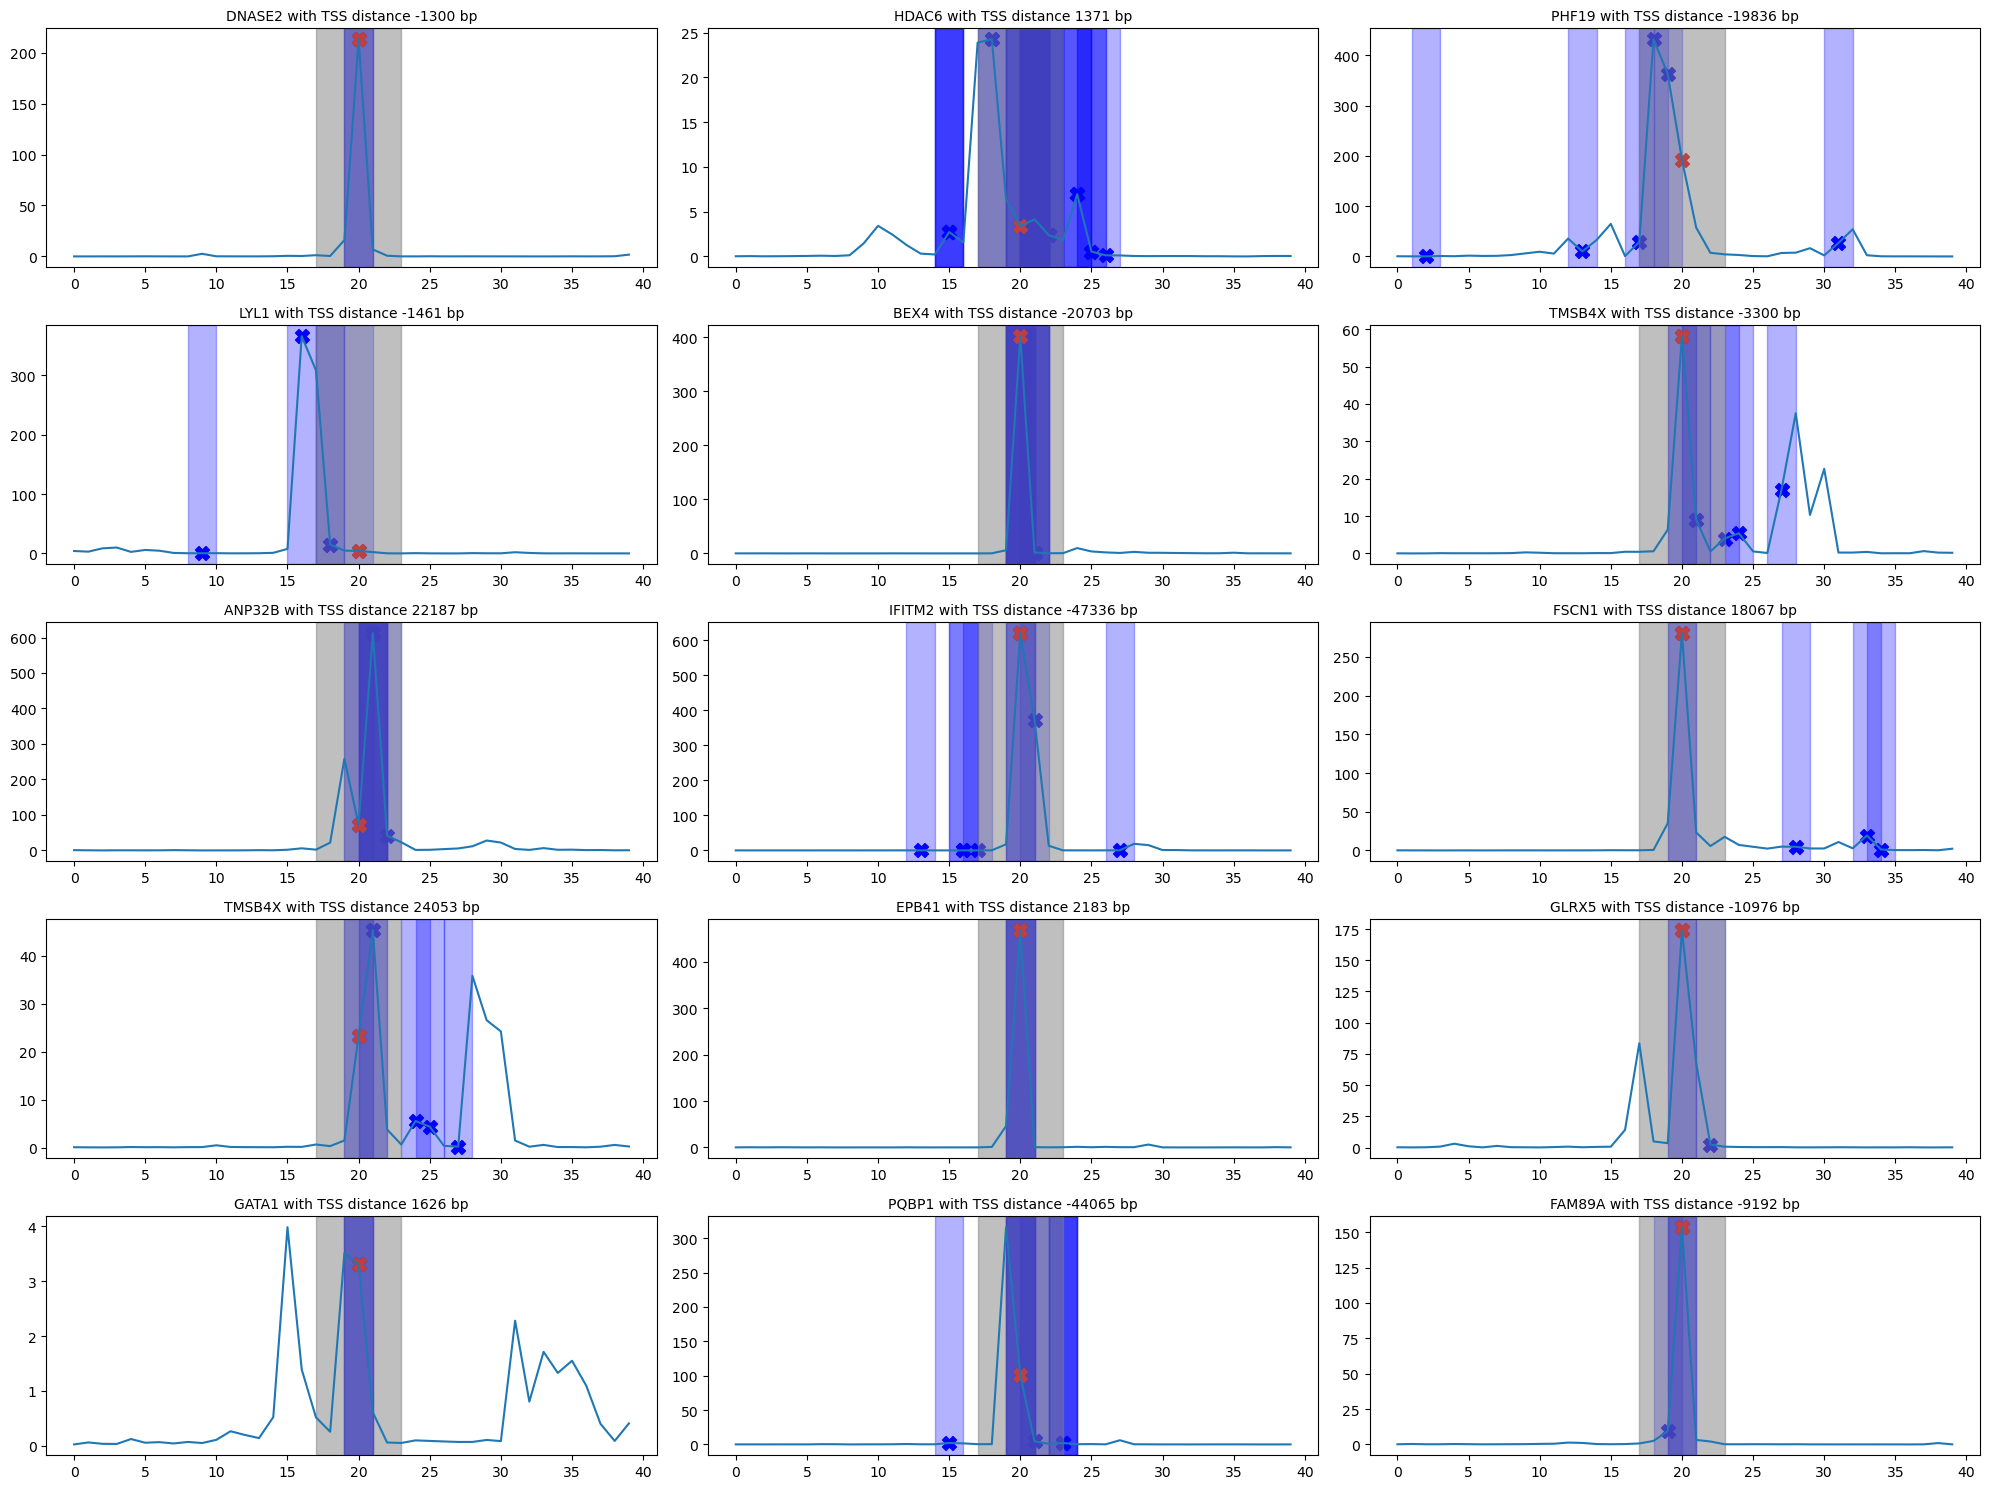

In [44]:
#now edit this to center around the tss still
plt.figure(figsize=(20,15))
i = 100
plot_idx = 1
while plot_idx < 16 and i < len(gs_df_regulated):
    idx_gs = i
    element = gs_df_regulated.iloc[idx_gs]
    #now tss info
    mid = (element['chromEnd']+element['chromStart'])//2
    chrom = element['chrom']
    ensgid = name_to_ensg.get(element['measuredGeneSymbol'], None)
    if ensgid is None:
        print(f"Skipping {element['measuredGeneSymbol']} because it is not in the name_to_ensg mapping")
        i += 1
        continue
    temp_tss = tss_dict[ensgid]['tss'] #this part of converting to ENSG needs to be done!
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss #do it relative to the main tss
    diff = temp_tss - mid
    if abs(diff) > 896//2*128: #if the tss is outside of the region we are looking at, then we can't really say much about it, so we skip it
        print(f"Skipping {element['measuredGeneSymbol']} because TSS is too far from the element")
        i += 1
        continue

    gene_location = 896//2 + diff//128

    #now get prediction of the model on this region
    idx = evals.dataset.expand_seqs(chrom,element['chromStart'], element['chromEnd'])
    (seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
    out = evals(data=((seq,acc), (seq_unmask, acc_unmask))).cpu().numpy().squeeze()

    dist_to_look = 20
    start_idx = gene_location - dist_to_look
    end_idx = gene_location + dist_to_look
    if gene_location - dist_to_look < 0 or gene_location + dist_to_look >= len(out):
        print(f"Skipping {element['measuredGeneSymbol']} because the region to look at is out of bounds")
        i += 1
        continue
    plt.subplot(5,3,plot_idx)
    plot_idx += 1
    plt.plot(out[gene_location - dist_to_look:gene_location + dist_to_look]) #let's just look at the region around the gene, does it have a peak there?
    #plot the alt tss as well
    for alt in alt_tss:
        alt_location_absolute = 896//2 + (diff + alt)//128
        alt_location_relative = alt_location_absolute - start_idx # Map to the zoomed x-axis
        # Check if the alt TSS falls within our zoomed-in 200-bin window
        if 0 <= alt_location_relative < (2 * dist_to_look): 
            # Use relative for X, but absolute for the original 'out' array Y
            plt.scatter(alt_location_relative, out[alt_location_absolute], color='b', marker='X', s=100)
            plt.axvspan(alt_location_relative-1, alt_location_relative+1, color='blue', alpha=0.3)
    plt.scatter(dist_to_look, out[gene_location], color='r', marker='X', s=100)

    #add grey bars up 2 and down 2 of the scatter
    plt.axvspan(dist_to_look-3, dist_to_look+3, color='gray', alpha=0.5)
    
    plt.title(f"{element['measuredGeneSymbol']} with TSS distance {diff} bp", fontsize=10)
    i += 1
plt.tight_layout()
plt.show()

In [31]:
element

dataset                                                 FlowFISH_K562
chrom                                                           chr17
chromStart                                                   32909510
chromEnd                                                     32913691
name                                 SPACA3|chr17:31236528-31240709:*
EffectSize                                                     -0.687
chrTSS                                                          chr17
startTSS                                                   32970376.0
endTSS                                                     32970377.0
measuredGeneSymbol                                             SPACA3
Significant                                                      True
pValueAdjusted                                                    NaN
PowerAtEffectSize25                                          0.359854
ValidConnection                                                  True
CellType            

In [ ]:
#this model is much more limited in how it can view context. We will make a script called _enformer to signify for enformer training data and info!

#biggest things to consider are that if we are near the edge of the center and that doing +/-3 will cut it off, then make sure min idx is 0 and max is 896

#also use the other promoters but look only 1 around, 3 around the main. And the key is to make a binary mask of the output we will use. Or we could even potentially just save out the whole thing?

#let's get an idea of how long this will take

#also if it's outside of the range, prediction should be same, can do 0 maybe?

In [ ]:
a = np.zeros((896,10000)).nbytes/1e9
print(f"Memory usage: {a:.2f} GB") #just 70 MB, that's perfectly fine to save out!

Memory usage: 0.07 GB


In [48]:
#then we don't even need TSS information except when we load it in. LEt's see how we could edit the gs_df by dropping rows where the gene isn't in the tss dict
#first add a column to the gs_df with the ensg id using the name_to_ensg mapping
gs_df['ensg_id'] = gs_df['measuredGeneSymbol'].map(name_to_ensg)
gs_df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214,ENSG00000116198
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214,ENSG00000130764
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848,ENSG00000130764
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214,ENSG00000235169
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848,ENSG00000235169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10407,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408,ENSG00000196976
10408,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569,ENSG00000102178
10409,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408,ENSG00000102178
10410,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408,ENSG00000130826


In [51]:
gs_df['ensg_id'].tolist()

['ENSG00000116198',
 'ENSG00000130764',
 'ENSG00000130764',
 'ENSG00000235169',
 'ENSG00000235169',
 'ENSG00000235169',
 'ENSG00000116251',
 'ENSG00000116288',
 'ENSG00000116288',
 'ENSG00000074800',
 'ENSG00000074800',
 'ENSG00000160049',
 'ENSG00000116670',
 'ENSG00000116670',
 'ENSG00000116670',
 'ENSG00000177674',
 'ENSG00000120948',
 'ENSG00000116649',
 'ENSG00000117118',
 nan,
 'ENSG00000053371',
 'ENSG00000053371',
 'ENSG00000077549',
 'ENSG00000077549',
 'ENSG00000053372',
 'ENSG00000053372',
 'ENSG00000053372',
 'ENSG00000127483',
 'ENSG00000173436',
 'ENSG00000070831',
 'ENSG00000070831',
 'ENSG00000070831',
 'ENSG00000090686',
 'ENSG00000117308',
 'ENSG00000117308',
 'ENSG00000142676',
 'ENSG00000142676',
 'ENSG00000142676',
 'ENSG00000142676',
 'ENSG00000142676',
 'ENSG00000125944',
 'ENSG00000125944',
 'ENSG00000011007',
 'ENSG00000057757',
 'ENSG00000133226',
 'ENSG00000183726',
 'ENSG00000183726',
 'ENSG00000183726',
 'ENSG00000117713',
 'ENSG00000198830',
 'ENSG00000198

In [53]:
#then we will drop the nans
gs_df = gs_df.dropna(subset=['ensg_id', 'Regulated'])
gs_df

,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214,ENSG00000116198
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214,ENSG00000130764
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848,ENSG00000130764
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214,ENSG00000235169
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848,ENSG00000235169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10407,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408,ENSG00000196976
10408,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569,ENSG00000102178
10409,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408,ENSG00000102178
10410,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408,ENSG00000130826


In [ ]:
#now let's see how we would loop through the values and how long it would take
from tqdm import tqdm

for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    chrom = row['chrom']
    start = row['chromStart']
    end = row['chromEnd']
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    #then we would load the data using the evals dataset and get the output and save it out
    idx = evals.dataset.expand_seqs(chrom, start, end)
    (seq,acc),(seq_unmask,acc_unmask) = evals.dataset[idx]
    out = evals(data=((seq,acc), (seq_unmask, acc_unmask))).cpu().numpy().squeeze()
    #then we would save out the output in a dictionary
    if i == 30:
        break
    #probalby 5 hours, 6 to stay safe?

  0%|          | 39/10356 [01:04<4:46:04,  1.66s/it]


KeyboardInterrupt: 

In [56]:
scale_factor = 100
dist_additional_mask = 100


for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    chrom = row['chrom']
    start = row['chromStart']
    end = row['chromEnd']
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    #then we would load the data using the evals dataset and get the output and save it out
    idx = evals.dataset.expand_seqs(chrom, start, end)

    ((s,a),(su,au)) = evals.dataset[idx]
    #now we add a batch dimension to s and a, and double the values
    s = s.unsqueeze(0).repeat(2, 1, 1) #now is 2 x 6 x 524288
    a = a.unsqueeze(0).repeat(2, 1, 1) #now is 2 x 2 x 524288
    #now we alter the values of the accessibility
    mask_len = end-start + dist_additional_mask*2
    startmask = 524288//2 - mask_len//2
    endmask = 524288//2 + mask_len//2
    a[1,0,startmask:endmask] = a[1,0,startmask:endmask] / scale_factor #reduce by 100 but not quite 0
    print(s.shape, a.shape)
    
    out = evals(data=((s,a), (None, None))).cpu().numpy().squeeze()
    print(out.shape)
    break

  0%|          | 0/10356 [00:00<?, ?it/s]

torch.Size([2, 6, 524288]) torch.Size([2, 2, 524288])


  0%|          | 0/10356 [00:04<?, ?it/s]

(2, 896)


In [64]:
row

dataset                                              FlowFISH_K562
chrom                                                         chr1
chromStart                                                 3774714
chromEnd                                                   3775214
name                                 CEP104|chr1:3691278-3691778:*
EffectSize                                               -0.293432
chrTSS                                                        chr1
startTSS                                                 3857213.0
endTSS                                                   3857214.0
measuredGeneSymbol                                          CEP104
Significant                                                   True
pValueAdjusted                                            0.004024
PowerAtEffectSize25                                       0.825094
ValidConnection                                               True
CellType                                                      

In [63]:
tss_dict[ensgid], start

({'chrom': 'chr1',
  'counts': 5.783194703376154,
  'tss': 3857233,
  'alt_tss': [3857414,
   3857223,
   3857225,
   3857194,
   3857387,
   3857198,
   3857199,
   3857168,
   3857723,
   3857233,
   3857396,
   3857209,
   3857211,
   3855901,
   3857214],
  'strand': '-',
  'split': 'train'},
 3774714)

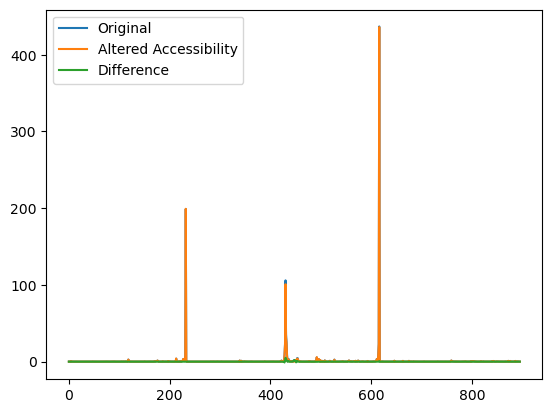

In [ ]:
plt.plot(out[0], label='Original')
plt.plot(out[1], label='Altered Accessibility')
plt.plot((out[0]-out[1]), label='Difference')
plt.legend()
plt.show()
#clearly see a difference!

In [67]:
#let's now time it again

for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    chrom = row['chrom']
    start = row['chromStart']
    end = row['chromEnd']
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    #then we would load the data using the evals dataset and get the output and save it out
    idx = evals.dataset.expand_seqs(chrom, start, end)

    ((s,a),(su,au)) = evals.dataset[idx]
    #now we add a batch dimension to s and a, and double the values
    s = s.unsqueeze(0).repeat(2, 1, 1) #now is 2 x 6 x 524288
    a = a.unsqueeze(0).repeat(2, 1, 1) #now is 2 x 2 x 524288
    #now we alter the values of the accessibility
    mask_len = end-start + dist_additional_mask*2
    startmask = 524288//2 - mask_len//2
    endmask = 524288//2 + mask_len//2
    a[1,0,startmask:endmask] = a[1,0,startmask:endmask] / scale_factor #reduce by 100 but not quite 0
    # print(s.shape, a.shape)
    
    out = evals(data=((s,a), (None, None))).cpu().numpy().squeeze()
    # print(out.shape)
    if i == 30:
        break
    #now like 10 hours because batch size is double and editing the data...
    #give it like 12 hours to be safe!

  0%|          | 29/10356 [01:38<9:46:08,  3.41s/it] 


# the way we would analyze the output

In [1]:
#so here's what we would load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t")

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

# gs_df_regulated = gs_df[gs_df["Regulated"] == True] #487
#now sort it by absolute value of EffectSize column
# gs_df_regulated = gs_df_regulated.reindex(gs_df_regulated["EffectSize"].abs().sort_values(ascending=False).index)

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)
    
name_to_ensg = tss.set_index('name')['Ensembl_ID'].to_dict()
#ensure all names are in the tss_dict
name_to_ensg = {name: ensg for name, ensg in name_to_ensg.items() if ensg in tss_dict}
        
gs_df['ensg_id'] = gs_df['measuredGeneSymbol'].map(name_to_ensg)
gs_df = gs_df.dropna(subset=['ensg_id', 'Regulated']).reset_index(drop=True)
gs_df


,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,Regulated,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214,ENSG00000116198
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214,ENSG00000130764
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,False,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848,ENSG00000130764
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,True,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214,ENSG00000235169
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,False,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848,ENSG00000235169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,False,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408,ENSG00000196976
10276,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,False,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569,ENSG00000102178
10277,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,False,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408,ENSG00000102178
10278,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,False,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408,ENSG00000130826


In [ ]:
#biggest things to consider are that if we are near the edge of the center and that doing +/-3 will cut it off, then make sure min idx is 0 and max is 896

#also use the other promoters but look only 1 around, 3 around the main. And the key is to make a binary mask of the output we will use. Or we could even potentially just save out the whole thing?

#also if it's outside of the range, prediction should be same, can do 0 maybe? But output of it should be ok!

In [21]:
#let's load in the vector
outputs = np.load('/data1/lesliec/sarthak/data/joint_playground/e2g/k562_unstranded_enformer.npy')
#for now we will just use random values
# outputs = np.random.rand(len(gs_df), 2, 896)
outputs.shape

(10280, 2, 896)

In [22]:
#so we have this matrix size 10k x 2 x 896
#first let's create our score vector
from tqdm import tqdm
score_vector = np.zeros(len(gs_df))
mask_len_maintss = 2
mask_len_alttss = 1
pseudo_count = 1e-2 #to avoid division by 0, we will add a small pseudo count to the sums
#now we loop through, apply a mask and score the value
for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    chrom = row['chrom']
    start = row['chromStart']
    end = row['chromEnd']
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    diff = temp_tss - ((start+end)//2)
    gene_location = 896//2 + diff//128

    #now we apply a mask to the output, we will look at a region of +/- 3 around the gene location, and set it to 0 in the altered accessibility condition
    if gene_location < -1 or gene_location > 896:
        score_vector[i] = 0
        continue
    startmask = max(0, gene_location - mask_len_maintss)
    endmask = min(896, gene_location + mask_len_maintss + 1)
    mask = np.zeros(896)
    mask[startmask:endmask] = 1
    if mask.sum() == 0:
        print('error: mask sum is 0, shouldn\'t happen')
        score_vector[i] = 0
        continue
    
    #now let's assign the alt tss masks
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
    if mask_len_alttss > 0:
        for alt in alt_tss:
            alt_location = 896//2 + (diff + alt)//128
            if alt_location < 0 or alt_location >= 896:
                continue
            
            alt_startmask = max(0, alt_location - mask_len_alttss)
            alt_endmask = min(896, alt_location + mask_len_alttss + 1)
            mask[alt_startmask:alt_endmask] = 1
    
    #now we apply the mask to the vector
    tempout = outputs[i] #2x896
    original_sum = (tempout[0] * mask).sum() #note sum and average will be identical for logfc
    altered_sum = (tempout[1] * mask).sum()
    score_vector[i] = np.log2((altered_sum + pseudo_count)/(original_sum + pseudo_count))
    

100%|██████████| 10280/10280 [00:00<00:00, 22941.94it/s]


In [15]:
score_vector

array([ 0.        , -0.99571072, -0.56108391, ...,  0.        ,
        0.        ,  0.        ])

AUPR: 0.3614


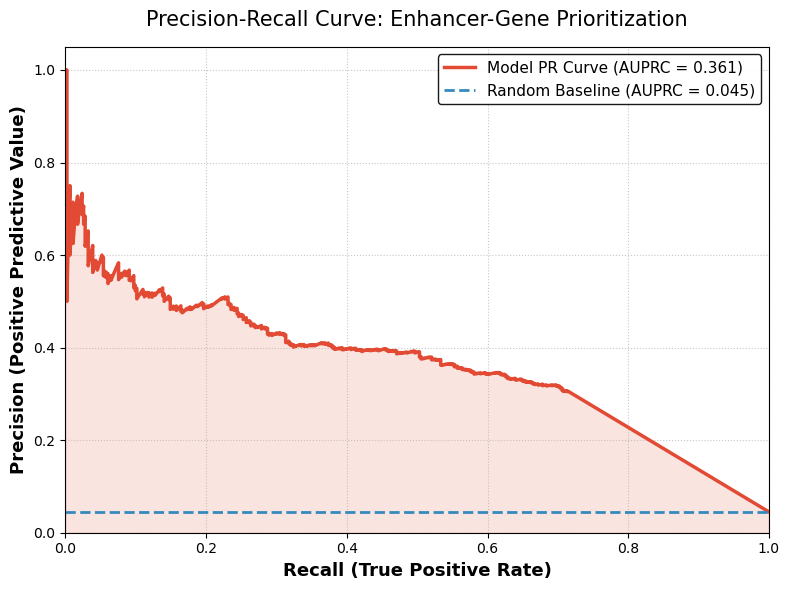

In [23]:
#I mean we  have random data, now we can do PRC curve and calculate AUPR
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(gs_df['Regulated'].astype(int), score_vector)
aupr = auc(recall, precision)
# print(f"AUPR: {aupr:.4f}")

# 1. Take absolute value of scores (magnitude of effect is the confidence!)
y_true = gs_df['Regulated'].astype(int)
y_score = np.abs(score_vector) #here doing absolute value for effect size!

# 2. Calculate Precision, Recall, and AUPRC
precision, recall, thresholds = precision_recall_curve(y_true, y_score)
aupr = auc(recall, precision)
print(f"AUPR: {aupr:.4f}")

# 3. Calculate the random baseline (Proportion of actual positives)
baseline = y_true.mean()

# 4. Create a nice, publication-ready plot
plt.figure(figsize=(8, 6))

# Plot the main PR curve
plt.plot(recall, precision, color='#E24A33', lw=2.5, label=f'Model PR Curve (AUPRC = {aupr:.3f})')

# Add a subtle shading under the curve for visual appeal
plt.fill_between(recall, precision, alpha=0.15, color='#E24A33')

# Plot the random guess baseline
plt.axhline(y=baseline, color='#348ABD', lw=2, linestyle='--', 
            label=f'Random Baseline (AUPRC = {baseline:.3f})')

# Format the axes and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Slight padding at the top
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Precision-Recall Curve: Enhancer-Gene Prioritization', fontsize=15, pad=15)

# Add a clean grid and legend
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')

# Clean up layout and display
plt.tight_layout()
plt.show()

In [ ]:
#16.5% is high? We would expect for random data that it is the prevalence of th enegative set
prevalence = gs_df['Regulated'].value_counts()
prevalence[True] / prevalence.sum()
#oh it is because we are masking and taking certain regions and most regions we take basically 0, so then lots of zeros in a zero biased model helps increase it?

0.045038910505836575

In [ ]:
prevalence #about 10 positive and 100 false thrown out somehow

Regulated
False    9817
True      463
Name: count, dtype: int64

In [ ]:
#we won't get real zeros like that

In [ ]:
#now calculate AUPR (with absolute value compared to regulated column), stratify it by distance
#correlate values with effect size, here don't use abs
#see if iit gets direction right, not size

#look at examples where large change but incorrect or no change but is correct, see if it's an actual change just we aren't including it in the mask

#play around with hyperparameters for mask and if we need to use alt tss!!
#that's about it!

In [24]:
#let's stratify by distance
#first create a distance column that uses the tss information
distance_vector = np.zeros(len(gs_df))
for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    chrom = row['chrom']
    start = row['chromStart']
    end = row['chromEnd']
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    distance_vector[i] = abs(temp_tss - ((start+end)//2))
gs_df['distance_to_tss'] = distance_vector
gs_df

100%|██████████| 10280/10280 [00:00<00:00, 14364.81it/s]


,dataset,chrom,chromStart,chromEnd,name,EffectSize,chrTSS,startTSS,endTSS,measuredGeneSymbol,...,PowerAtEffectSize10,PowerAtEffectSize15,PowerAtEffectSize20,PowerAtEffectSize50,pair_uid,merged_uid,merged_start,merged_end,ensg_id,distance_to_tss
0,FlowFISH_K562,chr1,3774714,3775214,CEP104|chr1:3691278-3691778:*,-0.293432,chr1,3857213.0,3857214.0,CEP104,...,NaN,NaN,NaN,NaN,FlowFISH_K562|CEP104|chr1:3691278-3691778:*,1,3774714,3775214,ENSG00000116198,82269.0
1,FlowFISH_K562,chr1,3774714,3775214,LRRC47|chr1:3691278-3691778:*,-0.331178,chr1,3796503.0,3796504.0,LRRC47,...,NaN,NaN,NaN,NaN,FlowFISH_K562|LRRC47|chr1:3691278-3691778:*,2,3774714,3775214,ENSG00000130764,21540.0
2,Gasperini2019,chr1,3803570,3805848,LRRC47|chr1:3720134-3722412:.,-0.001471,chr1,3796503.0,3796504.0,LRRC47,...,0.40,0.80,0.85,1.0,Gasperini2019|LRRC47|chr1:3720134-3722412:.,3,3803570,3805848,ENSG00000130764,8205.0
3,FlowFISH_K562,chr1,3774714,3775214,SMIM1|chr1:3691278-3691778:*,-0.472019,chr1,3772761.0,3772762.0,SMIM1,...,NaN,NaN,NaN,NaN,FlowFISH_K562|SMIM1|chr1:3691278-3691778:*,4,3774714,3775214,ENSG00000235169,2178.0
4,Gasperini2019,chr1,3803570,3805848,SMIM1|chr1:3720134-3722412:.,0.025677,chr1,3772788.0,3772789.0,SMIM1,...,0.80,0.85,1.00,1.0,Gasperini2019|SMIM1|chr1:3720134-3722412:.,5,3803570,3805848,ENSG00000235169,31923.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10275,Gasperini2019,chrX,155434755,155435408,LAGE3|chrX:154664416-154665069:.,0.012127,chrX,154479256.0,154479257.0,LAGE3,...,0.75,0.85,0.95,1.0,Gasperini2019|LAGE3|chrX:154664416-154665069:.,10408,155434755,155435408,ENSG00000196976,955824.0
10276,Gasperini2019,chrX,154527069,154527569,UBL4A|chrX:153755283-153755783:.,-0.006651,chrX,154486669.0,154486670.0,UBL4A,...,0.50,0.80,0.85,1.0,Gasperini2019|UBL4A|chrX:153755283-153755783:.,10409,154527069,154527569,ENSG00000102178,40649.0
10277,Gasperini2019,chrX,155434755,155435408,UBL4A|chrX:154664416-154665069:.,0.003708,chrX,154486669.0,154486670.0,UBL4A,...,0.70,0.85,0.95,1.0,Gasperini2019|UBL4A|chrX:154664416-154665069:.,10410,155434755,155435408,ENSG00000102178,948411.0
10278,Gasperini2019,chrX,155434755,155435408,DKC1|chrX:154664416-154665069:.,0.009955,chrX,154762742.0,154762743.0,DKC1,...,0.45,0.80,0.95,1.0,Gasperini2019|DKC1|chrX:154664416-154665069:.,10411,155434755,155435408,ENSG00000130826,672340.0


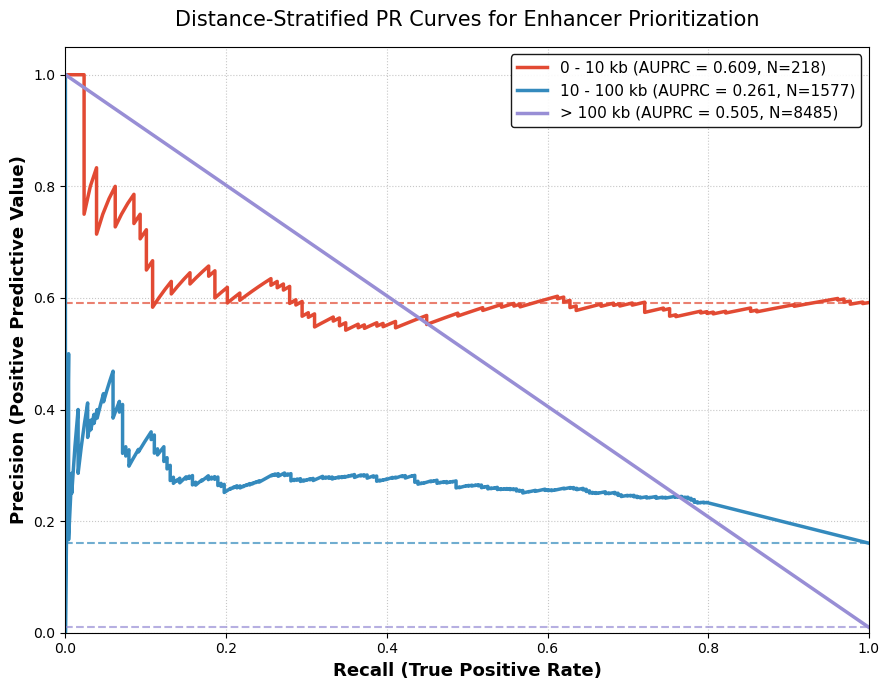

In [25]:
# 1. Prepare the data
y_true = gs_df['Regulated'].astype(int).values
y_score = np.abs(score_vector)
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", distances <= 10000),
    ("10 - 100 kb", (distances > 10000) & (distances <= 100000)),
    ("> 100 kb", distances > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

In [27]:
score_vector[distances > 100000].sum()

0.0

In [38]:
#let's do a new plot where we only plot values that are within the range, so if score is 0 it's ignored

score_vector = np.zeros(len(gs_df))
to_skip = np.zeros(len(gs_df), dtype=bool) #start with all True, meaning we skip all, then set to False for those we want to include
distances = np.zeros(len(gs_df))
mask_len_maintss = 2
mask_len_alttss = 1
pseudo_count = 1e-2 #to avoid division by 0, we will add a small pseudo count to the sums
#now we loop through, apply a mask and score the value
for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    chrom = row['chrom']
    start = row['chromStart']
    end = row['chromEnd']
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    diff = temp_tss - ((start+end)//2)
    distances[i] = np.abs(diff)
    gene_location = 896//2 + diff//128

    #now we apply a mask to the output, we will look at a region of +/- 3 around the gene location, and set it to 0 in the altered accessibility condition
    if gene_location < -1 or gene_location > 896:
        score_vector[i] = 0
        to_skip[i] = True
        continue
    startmask = max(0, gene_location - mask_len_maintss)
    endmask = min(896, gene_location + mask_len_maintss + 1)
    mask = np.zeros(896)
    mask[startmask:endmask] = 1
    if mask.sum() == 0:
        print('error: mask sum is 0, shouldn\'t happen')
        score_vector[i] = 0
        to_skip[i] = True
        continue
    
    #now let's assign the alt tss masks
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
    if mask_len_alttss > 0:
        for alt in alt_tss:
            alt_location = 896//2 + (diff + alt)//128
            if alt_location < 0 or alt_location >= 896:
                continue
            
            alt_startmask = max(0, alt_location - mask_len_alttss)
            alt_endmask = min(896, alt_location + mask_len_alttss + 1)
            mask[alt_startmask:alt_endmask] = 1
    
    #now we apply the mask to the vector
    tempout = outputs[i] #2x896
    original_sum = (tempout[0] * mask).sum() #note sum and average will be identical for logfc
    altered_sum = (tempout[1] * mask).sum()
    score_vector[i] = np.log2((altered_sum + pseudo_count)/(original_sum + pseudo_count))

100%|██████████| 10280/10280 [00:00<00:00, 21814.81it/s]


In [ ]:
to_skip.sum() - to_skip.shape #so 1000 of them are too far away
#wait my stratified plot is almost definitely wrong then, says N=8000 for > 100k...

array([-1084])

In [32]:
(distances > 100_000).sum()

8485

In [ ]:
#I recalcualted now
(distances > 100_000).sum()
#should only see things that are 57k away...

8485

(array([3661., 2568., 1690., 1448.,  499.,  157.,  113.,   94.,   42.,
           8.]),
 array([1.1770000e+03, 2.3856690e+05, 4.7595680e+05, 7.1334670e+05,
        9.5073660e+05, 1.1881265e+06, 1.4255164e+06, 1.6629063e+06,
        1.9002962e+06, 2.1376861e+06, 2.3750760e+06]),
 <BarContainer object of 10 artists>)

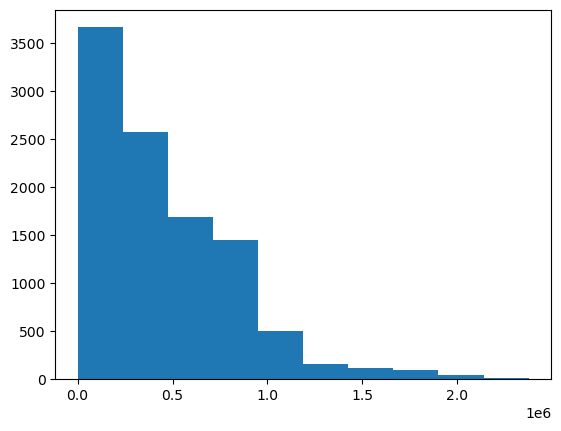

In [35]:
#huh do a histogram
plt.hist(distances)

Skipping > 100 kb: No pairs in this distance range.


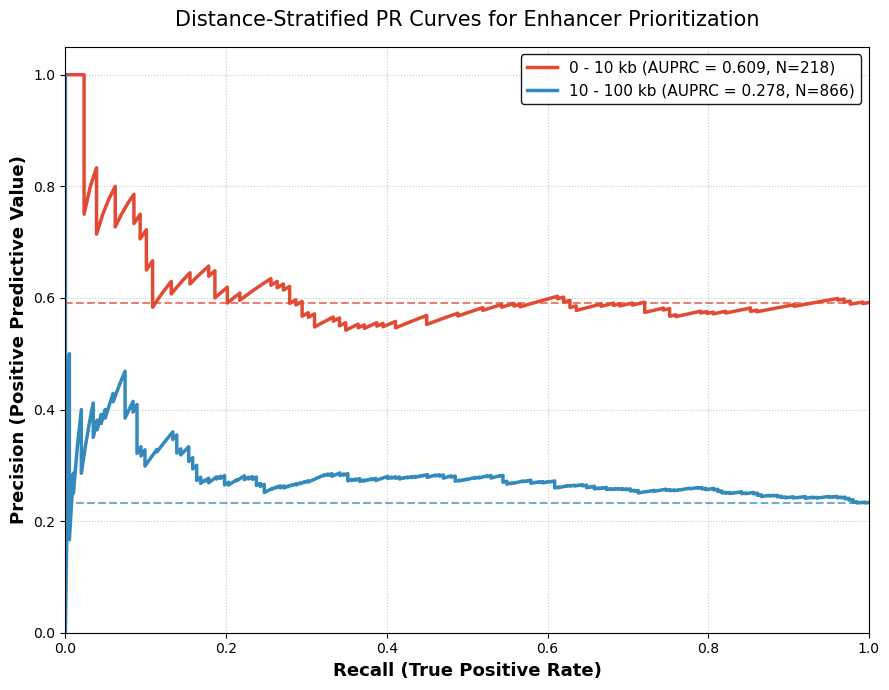

In [37]:
#let's redo AUPRC with only those that are not skipped
#wait it's skipping almost all of them lmao!

y_true = gs_df['Regulated'].astype(int).values
y_true = y_true[~to_skip]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[~to_skip]  # Remove skipped values
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 
distances = distances[~to_skip]  # Remove skipped values

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", distances <= 10000),
    ("10 - 100 kb", (distances > 10000) & (distances <= 100000)),
    ("> 100 kb", distances > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

In [42]:
#we can also just use main TSS
#wait it won't help if we are masking them all anyways...
#let's do a new plot where we only plot values that are within the range, so if score is 0 it's ignored

score_vector = np.zeros(len(gs_df))
to_skip = np.zeros(len(gs_df), dtype=bool) #start with all True, meaning we skip all, then set to False for those we want to include
distances = np.zeros(len(gs_df))
mask_len_maintss = 2
mask_len_alttss = 0
pseudo_count = 1e-2 #to avoid division by 0, we will add a small pseudo count to the sums
#now we loop through, apply a mask and score the value
for i, row in tqdm(gs_df.iterrows(), total=len(gs_df)):
    chrom = row['chrom']
    start = row['chromStart']
    end = row['chromEnd']
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    diff = temp_tss - ((start+end)//2)
    distances[i] = np.abs(diff)
    gene_location = 896//2 + diff//128

    #now we apply a mask to the output, we will look at a region of +/- 3 around the gene location, and set it to 0 in the altered accessibility condition
    if gene_location < -1 or gene_location > 896:
        score_vector[i] = 0
        to_skip[i] = True
        continue
    startmask = max(0, gene_location - mask_len_maintss)
    endmask = min(896, gene_location + mask_len_maintss + 1)
    mask = np.zeros(896)
    mask[startmask:endmask] = 1
    if mask.sum() == 0:
        print('error: mask sum is 0, shouldn\'t happen')
        score_vector[i] = 0
        to_skip[i] = True
        continue
    
    #now let's assign the alt tss masks
    alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss
    if mask_len_alttss > 0:
        for alt in alt_tss:
            alt_location = 896//2 + (diff + alt)//128
            if alt_location < 0 or alt_location >= 896:
                continue
            
            alt_startmask = max(0, alt_location - mask_len_alttss)
            alt_endmask = min(896, alt_location + mask_len_alttss + 1)
            mask[alt_startmask:alt_endmask] = 1
    
    #now we apply the mask to the vector
    tempout = outputs[i] #2x896
    original_sum = (tempout[0] * mask).sum() #note sum and average will be identical for logfc
    altered_sum = (tempout[1] * mask).sum()
    score_vector[i] = np.log2((altered_sum + pseudo_count)/(original_sum + pseudo_count))

100%|██████████| 10280/10280 [00:00<00:00, 22259.23it/s]


Skipping > 100 kb: No pairs in this distance range.


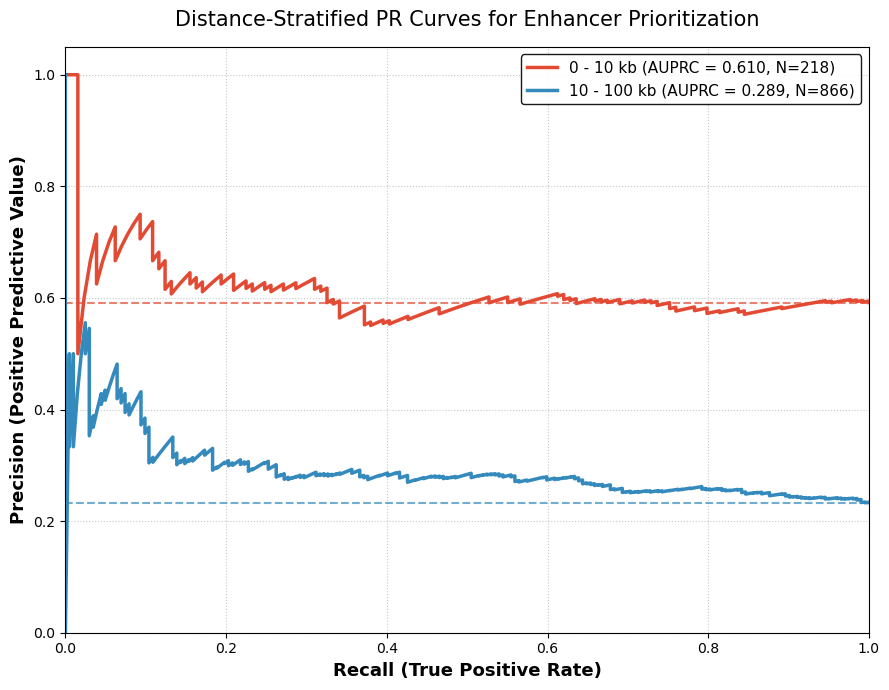

In [ ]:
#let's redo AUPRC with only those that are not skipped
#wait it's skipping almost all of them lmao!

y_true = gs_df['Regulated'].astype(int).values
y_true = y_true[~to_skip]  # Remove skipped values
y_score = np.abs(score_vector)
y_score = y_score[~to_skip]  # Remove skipped values
# Ensure distances are positive (in case your vector has signed downstream/upstream distances)
distances = np.abs(distance_vector) 
distances_temp = distances[~to_skip]  # Remove skipped values

# 2. Define the distance masks
bins = [
    ("0 - 10 kb", distances_temp <= 10000),
    ("10 - 100 kb", (distances_temp > 10000) & (distances_temp <= 100000)),
    ("> 100 kb", distances_temp > 100000)
]

# 3. Setup the plot
plt.figure(figsize=(9, 7))
colors = ['#E24A33', '#348ABD', '#988ED5'] # Red, Blue, Purple for distinctiveness

# 4. Loop through each stratification, calculate AUPRC, and plot
for (label, mask), color in zip(bins, colors):
    if mask.sum() == 0:
        print(f"Skipping {label}: No pairs in this distance range.")
        continue
        
    # Subset the labels and predictions
    y_true_sub = y_true[mask]
    y_score_sub = y_score[mask]
    
    # Calculate PR curve and AUPRC
    precision, recall, _ = precision_recall_curve(y_true_sub, y_score_sub)
    aupr = auc(recall, precision)
    
    # Calculate the baseline (proportion of positives in THIS specific distance bin)
    baseline = y_true_sub.mean()
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2.5, 
             label=f'{label} (AUPRC = {aupr:.3f}, N={mask.sum()})')
    
    # Plot the corresponding baseline
    plt.axhline(y=baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (True Positive Rate)', fontsize=13, fontweight='bold')
plt.ylabel('Precision (Positive Predictive Value)', fontsize=13, fontweight='bold')
plt.title('Distance-Stratified PR Curves for Enhancer Prioritization', fontsize=15, pad=15)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc="upper right", fontsize=11, framealpha=0.9, edgecolor='black')
plt.tight_layout()
plt.show()

In [ ]:
(distances < 262144).sum() #so now 4000 of them are in range? Including the full 100k section!

3956